# Airline Passenger Satisfaction — ML Pipeline
**Môn học:** Học Máy (CS114) | **Học kỳ II — Năm học 2025–2026**  
**Trường:** Đại học Bách Khoa, ĐHQG-HCM  
**GVHD:** TS. Lê Thành Sách

---

## Mục tiêu
Xây dựng pipeline học máy truyền thống **và** học sâu để dự đoán mức độ hài lòng của hành khách hàng không từ dữ liệu khảo sát dạng bảng.

**Pipeline tổng quát:**  
`EDA → Tiền xử lý → Feature Engineering → Model Zoo (CV) → Tuning → Evaluation → So sánh Traditional vs Deep Learning`

---

## Cấu trúc notebook
| Phần | Nội dung |
|------|----------|
| 0 | Setup, cấu hình, tải dữ liệu |
| 1 | EDA chuyên sâu (Data Profiling, Univariate, Bivariate, Multivariate, Feature Engineering) |
| 2 | Traditional ML Pipeline (Baseline → Model Zoo → Tuning → Evaluation) |
| 3 | Deep Learning Pipeline (MLP, ResMLP, WideDeep, TabNetLite, FTTransformer) |
| 4 | Reload & Reproduce (sau reset kernel) |
| 5 | Summary & So sánh |

> **Yêu cầu:** Runtime → Run all phải chạy thành công 100% không lỗi.

---
# 0. Setup & Configuration

In [2]:
# ── 0.1 Install extra dependencies ───────────────────────────────────────────
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install('kagglehub')
print("Dependencies ready.")

Dependencies ready.


In [3]:
# ── 0.2 Global configuration & seeds ─────────────────────────────────────────
import os, json, warnings, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42

def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(RANDOM_STATE)

# ── Paths ─────────────────────────────────────────────────────────────────────
OUT_DIR       = Path("outputs")
DATA_DIR      = OUT_DIR / "data"
ARTIFACTS_DIR = OUT_DIR / "artifacts"
FEATURES_DIR  = OUT_DIR / "features"
EDA_DIR       = OUT_DIR / "eda_outputs"

for d in [OUT_DIR, DATA_DIR, ARTIFACTS_DIR, FEATURES_DIR, EDA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Visual style ──────────────────────────────────────────────────────────────
PALETTE  = ['#2196F3', '#FF5722']
BG_COLOR = '#F8F9FA'
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.facecolor': BG_COLOR, 'axes.facecolor': BG_COLOR,
                     'axes.spines.top': False, 'axes.spines.right': False})

# ── Dataset info ──────────────────────────────────────────────────────────────
TARGET_COL          = 'satisfaction'
DROP_COLS_CANDIDATES = ['Unnamed: 0', 'id']
FAST_MODE           = False   # ← đặt True để chạy nhanh hơn (ít fold, ít model)

print("Config complete.")
print(f"   OUT_DIR   : {OUT_DIR.resolve()}")
print(f"   FAST_MODE : {FAST_MODE}")

Config complete.
   OUT_DIR   : /content/outputs
   FAST_MODE : False


## 0.3 Download & Load Data

In [4]:
# ── 0.3 Download từ Kaggle (public, không cần mount Drive) ───────────────────
import shutil, kagglehub

DATASET = 'teejmahal20/airline-passenger-satisfaction'

train_path = DATA_DIR / 'train.csv'
test_path  = DATA_DIR / 'test.csv'

if train_path.exists() and test_path.exists():
    print("📂 Using cached data.")
else:
    print("📥 Downloading from Kaggle...")
    src = Path(kagglehub.dataset_download(DATASET))
    for fname in ['train.csv', 'test.csv']:
        shutil.copy2(src / fname, DATA_DIR / fname)
    print("Download complete.")

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print(f"Train: {train_df.shape} | Test: {test_df.shape}")
train_df.head(3)

📥 Downloading from Kaggle...
Using Colab cache for faster access to the 'airline-passenger-satisfaction' dataset.
Download complete.
Train: (103904, 25) | Test: (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied


In [5]:
# ── 0.4 Split X/y và xác định vai trò cột ─────────────────────────────────────
target_map = {'neutral or dissatisfied': 0, 'satisfied': 1}

drop_cols = [c for c in DROP_COLS_CANDIDATES if c in train_df.columns]

X_full = train_df.drop(columns=[TARGET_COL] + drop_cols)
y_full = train_df[TARGET_COL].map(target_map)

X_test = test_df.drop(columns=[TARGET_COL] + drop_cols, errors='ignore')
y_test = test_df[TARGET_COL].map(target_map) if TARGET_COL in test_df.columns else None

# Column roles (used by EDA + ML pipeline)
num_cols = X_full.select_dtypes('number').columns.tolist()
cat_cols = X_full.select_dtypes('object').columns.tolist()

# For EDA: distinguish rating vs continuous numeric
rating_cols = [c for c in num_cols if X_full[c].nunique() <= 6 and X_full[c].min() >= 0]
cont_cols   = [c for c in num_cols if c not in rating_cols]
delay_cols  = [c for c in cont_cols if 'delay' in c.lower()]

# For EDA on raw df (including target)
df = train_df.copy()
target_labels = df[TARGET_COL].value_counts().index.tolist()
PALETTE_D = {lbl: col for lbl, col in zip(target_labels, PALETTE)}

print(f"X_full : {X_full.shape} | X_test : {X_test.shape}")
print(f"Categorical ({len(cat_cols)}) : {cat_cols}")
print(f"Continuous  ({len(cont_cols)}): {cont_cols}")
print(f"Rating      ({len(rating_cols)}): {rating_cols[:5]}{'...' if len(rating_cols)>5 else ''}")
print(f"Delay       ({len(delay_cols)}): {delay_cols}")

X_full : (103904, 22) | X_test : (25976, 22)
Categorical (4) : ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Continuous  (4): ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Rating      (14): ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink']...
Delay       (2): ['Departure Delay in Minutes', 'Arrival Delay in Minutes']


---
# 1. EDA — Exploratory Data Analysis

EDA được thực hiện **toàn diện** theo quy trình: Data Profiling → Target Analysis → Univariate → Bivariate → Multivariate → Outlier & Feature Engineering → Summary.  
Tất cả insights được tính **tự động** từ dữ liệu (không hardcode) để đảm bảo tính tái sử dụng.

## 1.1 Data Profiling

In [6]:
# 1.1 Dataset health check
print(f"{'='*60}")
print(f"  DATASET OVERVIEW")
print(f"{'='*60}")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"{'='*60}\n")

missing  = df.isnull().sum()
miss_pct = (missing / len(df) * 100).round(3)

profile = pd.DataFrame({
    'Dtype':     df.dtypes,
    'Non-Null':  df.notnull().sum(),
    'Missing':   missing,
    'Missing %': miss_pct,
    'Unique':    df.nunique(),
}).sort_values('Missing %', ascending=False)

display(profile)

# Missing value analysis
miss_only = profile[profile['Missing'] > 0]
if miss_only.empty:
    print('No missing values.')
else:
    print('  Columns with missing values:')
    for col in miss_only.index:
        pct = miss_only.loc[col, 'Missing %']
        dtype = df[col].dtype
        if pct < 1:
            strategy = 'impute with median (non-systematic)'
        elif pct < 20:
            strategy = 'impute with median / KNN imputer'
        else:
            strategy = 'consider dropping or advanced imputation'
        print(f"   • {col}: {miss_only.loc[col,'Missing']:,} rows ({pct:.3f}%) [{dtype}] → {strategy}")

n_dup = df.duplicated().sum()
print(f"\nDuplicates: {n_dup:,}", '→ removed.' if n_dup > 0 else '→ none.')
if n_dup > 0:
    df.drop_duplicates(inplace=True)

print('\nDescriptive statistics (numeric):')
display(df[num_cols].describe().T.round(2))

  DATASET OVERVIEW
  Rows    : 103,904
  Columns : 25
  Memory  : 48.0 MB



,Dtype,Non-Null,Missing,Missing %,Unique
Arrival Delay in Minutes,float64,103594,310,0.298,455
id,int64,103904,0,0.000,103904
Gender,object,103904,0,0.000,2
Customer Type,object,103904,0,0.000,2
Age,int64,103904,0,0.000,75
Type of Travel,object,103904,0,0.000,2
Class,object,103904,0,0.000,3
Flight Distance,int64,103904,0,0.000,3802
Unnamed: 0,int64,103904,0,0.000,103904
Inflight wifi service,int64,103904,0,0.000,6


  Columns with missing values:
   • Arrival Delay in Minutes: 310 rows (0.298%) [float64] → impute with median (non-systematic)

Duplicates: 0 → none.

Descriptive statistics (numeric):


,count,mean,std,min,25%,50%,75%,max
Age,103904.0,39.38,15.11,7.0,27.0,40.0,51.0,85.0
Flight Distance,103904.0,1189.45,997.15,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,2.73,1.33,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,3.06,1.53,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,103904.0,2.76,1.40,0.0,2.0,3.0,4.0,5.0
Gate location,103904.0,2.98,1.28,0.0,2.0,3.0,4.0,5.0
Food and drink,103904.0,3.20,1.33,0.0,2.0,3.0,4.0,5.0
Online boarding,103904.0,3.25,1.35,0.0,2.0,3.0,4.0,5.0
Seat comfort,103904.0,3.44,1.32,0.0,2.0,4.0,5.0,5.0
Inflight entertainment,103904.0,3.36,1.33,0.0,2.0,4.0,4.0,5.0


## 1.2 Target Variable — Class Balance

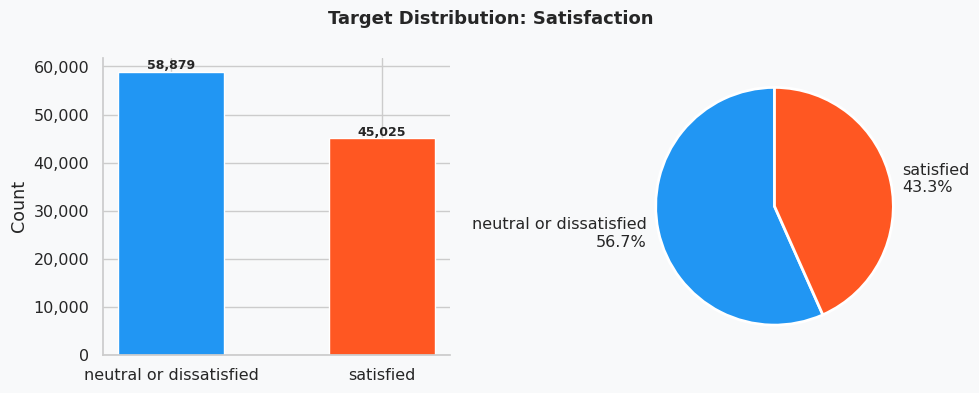


neutral or dissatisfied: 56.7% | satisfied: 43.3%
   Imbalance ratio: 1.31x — well-balanced.


In [7]:
# 1.2 Target distribution
counts = df[TARGET_COL].value_counts()
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f'Target Distribution: {TARGET_COL.title()}', fontsize=13, fontweight='bold')

offset = counts.max() * 0.01
bars = axes[0].bar(counts.index, counts.values,
                   color=PALETTE[:len(counts)], edgecolor='white', width=0.5)
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=9)

axes[1].pie(counts.values,
            labels=[f'{l}\n{p:.1f}%' for l, p in zip(counts.index, pcts)],
            colors=PALETTE[:len(counts)], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))

plt.tight_layout()
plt.show()

ratio = pcts.iloc[0] / pcts.iloc[-1]
print(f'\n{target_labels[0]}: {pcts.iloc[0]:.1f}% | {target_labels[-1]}: {pcts.iloc[-1]:.1f}%')
print(f'   Imbalance ratio: {ratio:.2f}x', end=' ')
print('— well-balanced.' if ratio < 1.5 else ('— moderate, use stratified splits.' if ratio < 3 else '— significant, consider resampling.'))

## 1.3 Univariate Analysis — Categorical Features

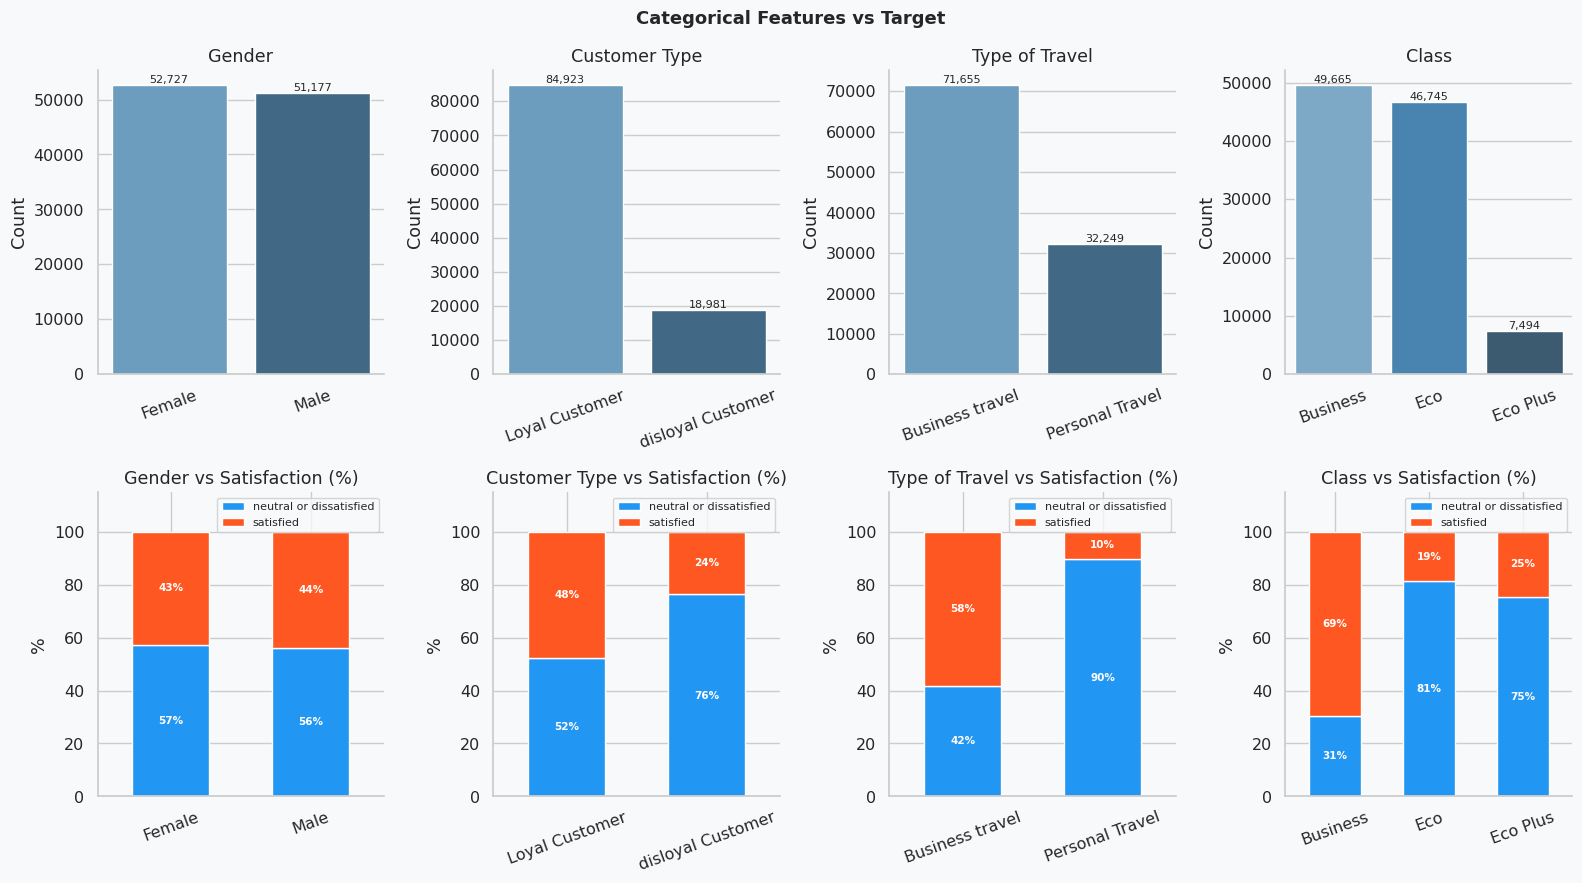


Insights:
   • Gender: "Male" most satisfied (44%), "Female" least (43%)
   • Customer Type: "Loyal Customer" most satisfied (48%), "disloyal Customer" least (24%)
   • Type of Travel: "Business travel" most satisfied (58%), "Personal Travel" least (10%)
   • Class: "Business" most satisfied (69%), "Eco" least (19%)


In [8]:
# 1.3 Categorical: count + stacked % vs target
n = len(cat_cols)
fig, axes = plt.subplots(2, n, figsize=(n * 4, 9))
fig.suptitle('Categorical Features vs Target', fontsize=13, fontweight='bold')
if n == 1:
    axes = axes.reshape(2, 1)

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index

    sns.countplot(data=df, x=col, ax=axes[0, i], order=order, palette='Blues_d')
    axes[0, i].set_title(f'{col}')
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('Count')
    axes[0, i].tick_params(axis='x', rotation=20)
    for p in axes[0, i].patches:
        axes[0, i].annotate(f'{int(p.get_height()):,}',
                            (p.get_x() + p.get_width()/2, p.get_height()),
                            ha='center', va='bottom', fontsize=8)

    ct = pd.crosstab(df[col], df[TARGET_COL], normalize='index').reindex(order) * 100
    ct.plot(kind='bar', stacked=True, ax=axes[1, i],
            color=PALETTE[:len(ct.columns)], edgecolor='white', width=0.55)
    axes[1, i].set_title(f'{col} vs {TARGET_COL.title()} (%)')
    axes[1, i].set_xlabel('')
    axes[1, i].set_ylabel('%')
    axes[1, i].set_ylim(0, 115)
    axes[1, i].tick_params(axis='x', rotation=20)
    axes[1, i].legend(fontsize=8, loc='upper right')
    for p in axes[1, i].patches:
        h = p.get_height()
        if h > 6:
            axes[1, i].text(p.get_x() + p.get_width()/2, p.get_y() + h/2,
                            f'{h:.0f}%', ha='center', va='center',
                            fontsize=7.5, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

sat_label = target_labels[-1]
print('\nInsights:')
for col in cat_cols:
    sat_rate = df.groupby(col)[TARGET_COL].apply(lambda x: (x == sat_label).mean() * 100)
    best, worst = sat_rate.idxmax(), sat_rate.idxmin()
    print(f'   • {col}: "{best}" most satisfied ({sat_rate[best]:.0f}%), "{worst}" least ({sat_rate[worst]:.0f}%)')

## 1.4 Univariate Analysis — Continuous Features

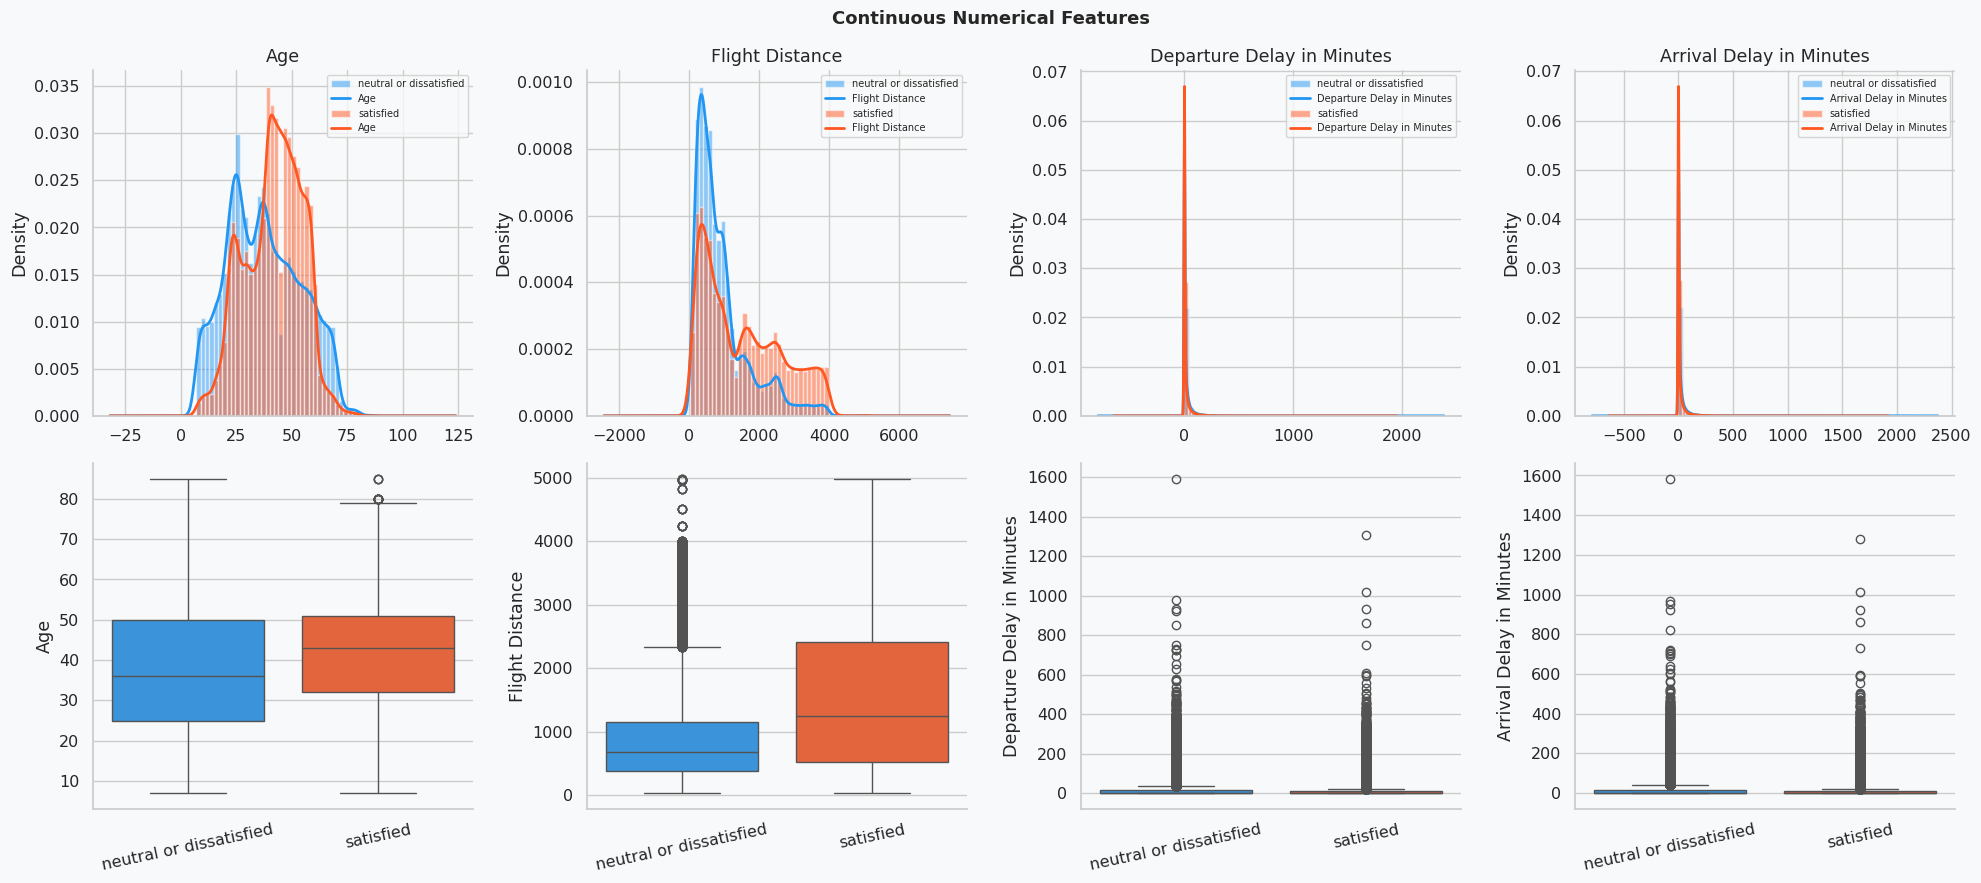


Insights:
   • Age: skewness=-0.00 (approx. normal), 0 outliers above IQR fence
   • Flight Distance: skewness=1.11 (right-skewed), 2,291 outliers above IQR fence
   • Departure Delay in Minutes: skewness=6.73 (right-skewed), 14,529 outliers above IQR fence
   • Arrival Delay in Minutes: skewness=6.60 (right-skewed), 13,954 outliers above IQR fence


In [9]:
# 1.4 Continuous numerics: histogram+KDE + boxplot by target
n = len(cont_cols)
fig, axes = plt.subplots(2, n, figsize=(n * 5, 9))
fig.suptitle('Continuous Numerical Features', fontsize=13, fontweight='bold')
if n == 1:
    axes = axes.reshape(2, 1)

for i, col in enumerate(cont_cols):
    for label, color in zip(target_labels, PALETTE):
        subset = df[df[TARGET_COL] == label][col].dropna()
        axes[0, i].hist(subset, bins=40, alpha=0.5, color=color, label=label, density=True)
        subset.plot.kde(ax=axes[0, i], color=color, linewidth=2)
    axes[0, i].set_title(col)
    axes[0, i].set_ylabel('Density')
    axes[0, i].legend(fontsize=7)

    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[1, i],
                palette=PALETTE_D, order=target_labels)
    axes[1, i].set_xlabel('')
    axes[1, i].tick_params(axis='x', rotation=12)

plt.tight_layout()
plt.show()

print('\nInsights:')
for col in cont_cols:
    skew = df[col].skew()
    iqr  = df[col].quantile(0.75) - df[col].quantile(0.25)
    n_out = (df[col] > df[col].quantile(0.75) + 1.5 * iqr).sum()
    desc = 'right-skewed' if skew > 1 else ('left-skewed' if skew < -1 else 'approx. normal')
    print(f'   • {col}: skewness={skew:.2f} ({desc}), {n_out:,} outliers above IQR fence')

## 1.5 Univariate Analysis — Rating Features (0–5)

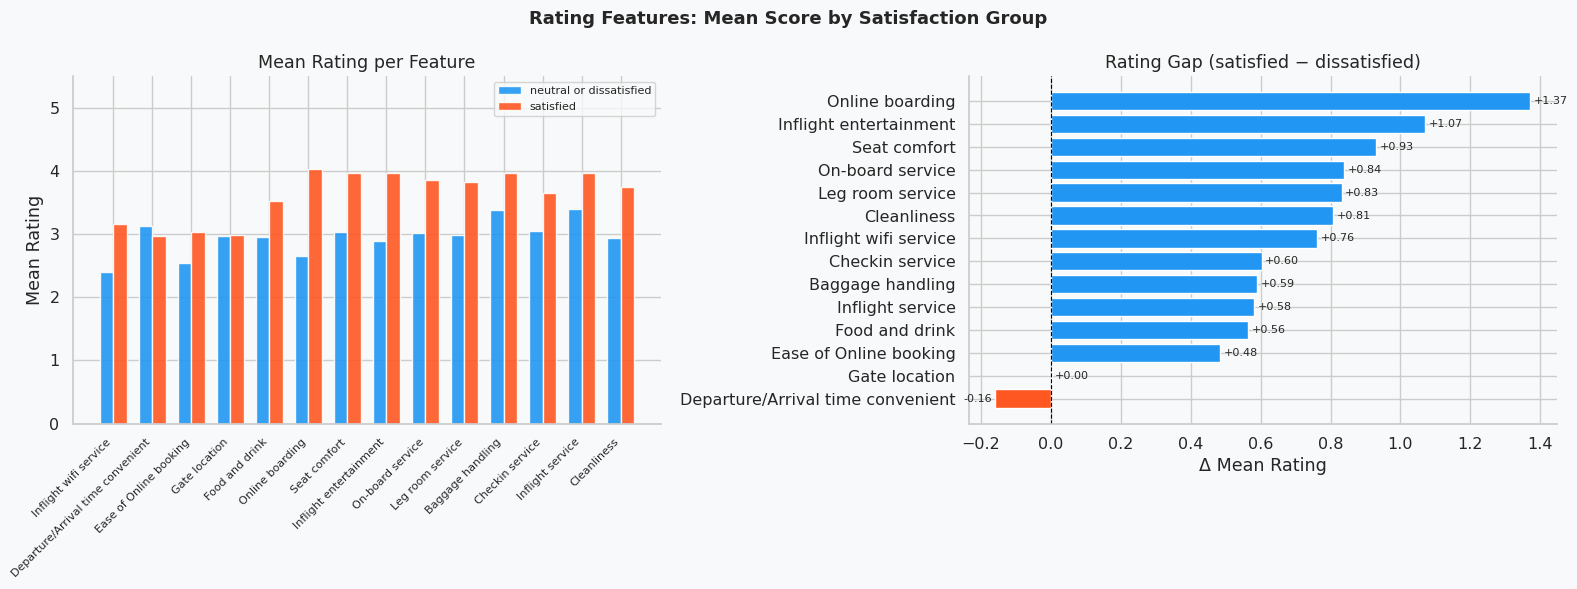


Insights:
   • Most discriminative ratings: ['Online boarding', 'Inflight entertainment', 'Seat comfort']
   • Least discriminative ratings: ['Gate location', 'Departure/Arrival time convenient', 'Ease of Online booking']


In [10]:
# 1.5 Rating features analysis
mean_ratings = df.groupby(TARGET_COL)[rating_cols].mean()
diff = (mean_ratings.loc[target_labels[-1]] - mean_ratings.loc[target_labels[0]]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Rating Features: Mean Score by Satisfaction Group', fontsize=13, fontweight='bold')

x      = np.arange(len(rating_cols))
width  = 0.35
for k, (label, color) in enumerate(zip(target_labels, PALETTE)):
    axes[0].bar(x + k * width, mean_ratings.loc[label], width,
                label=label, color=color, edgecolor='white', alpha=0.9)
axes[0].set_xticks(x + width / 2)
axes[0].set_xticklabels(rating_cols, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Mean Rating')
axes[0].set_ylim(0, 5.5)
axes[0].legend(fontsize=8)
axes[0].set_title('Mean Rating per Feature')

colors_gap = [PALETTE[1] if v < 0 else PALETTE[0] for v in diff.values]
axes[1].barh(diff.index, diff.values, color=colors_gap, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Rating Gap (satisfied − dissatisfied)')
axes[1].set_xlabel('Δ Mean Rating')
for i, v in enumerate(diff.values):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:+.2f}',
                 va='center', fontsize=8, ha='left' if v >= 0 else 'right')

plt.tight_layout()
plt.show()

print('\nInsights:')
top3 = diff.abs().nlargest(3)
bot3 = diff.abs().nsmallest(3)
print(f'   • Most discriminative ratings: {list(top3.index)}')
print(f'   • Least discriminative ratings: {list(bot3.index)}')

## 1.6 Correlation Analysis

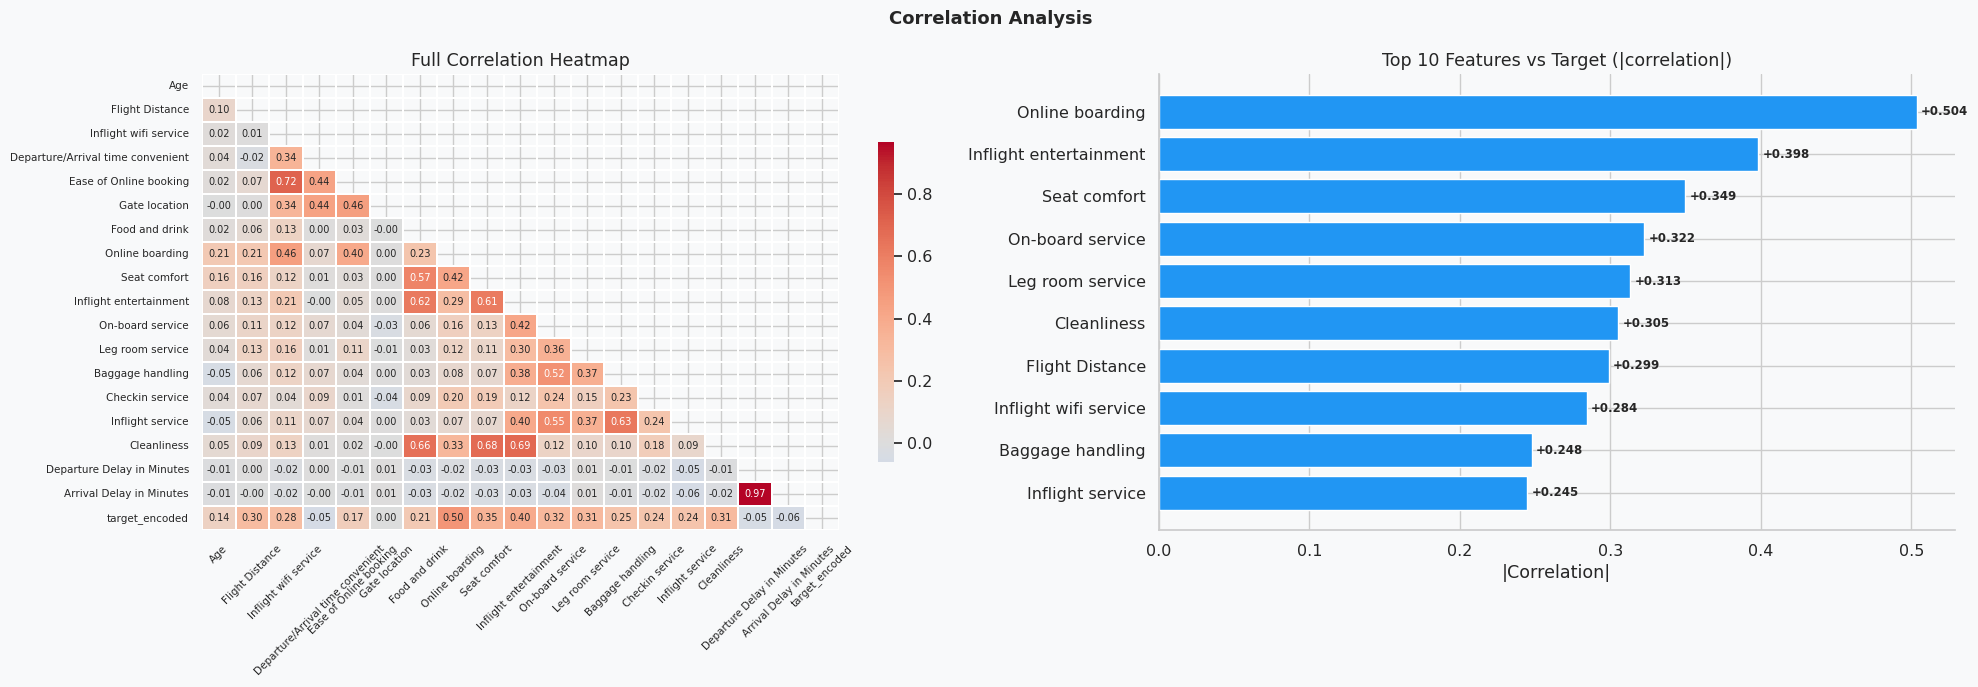


Insights:
   • Top correlated with target: "Online boarding" (r=+0.504), "Inflight entertainment" (r=+0.398)
   • Multicollinearity: "Departure Delay in Minutes" & "Arrival Delay in Minutes" (r=0.965)


In [11]:
# 1.6 Correlation heatmap + top features vs target
df_corr = df.copy()
df_corr['target_encoded'] = (df_corr[TARGET_COL] == target_labels[-1]).astype(int)

feat_cols   = [c for c in df_corr.select_dtypes('number').columns
               if c not in ['target_encoded'] + DROP_COLS_CANDIDATES]
corr_matrix = df_corr[feat_cols + ['target_encoded']].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Correlation Analysis', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[0],
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.3, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7})
axes[0].set_title('Full Correlation Heatmap')
axes[0].tick_params(axis='x', rotation=45, labelsize=7.5)
axes[0].tick_params(axis='y', rotation=0,  labelsize=7.5)

target_corr = corr_matrix['target_encoded'].drop('target_encoded').abs().sort_values()
top10       = target_corr.tail(10)
bar_colors  = [PALETTE[0] if corr_matrix['target_encoded'][f] > 0 else PALETTE[1] for f in top10.index]
axes[1].barh(top10.index, top10.values, color=bar_colors, edgecolor='white')
axes[1].set_title('Top 10 Features vs Target (|correlation|)')
axes[1].set_xlabel('|Correlation|')
for i, (feat, v) in enumerate(zip(top10.index, top10.values)):
    sign = '+' if corr_matrix['target_encoded'][feat] > 0 else '-'
    axes[1].text(v + 0.003, i, f'{sign}{v:.3f}', va='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.show()

top1, top2 = target_corr.index[-1], target_corr.index[-2]
r1 = corr_matrix['target_encoded'][top1]
r2 = corr_matrix['target_encoded'][top2]

feat_only = corr_matrix.drop('target_encoded').drop('target_encoded', axis=1)
high_pairs = [(feat_only.columns[i], feat_only.columns[j], feat_only.iloc[i, j])
              for i in range(len(feat_only)) for j in range(i+1, len(feat_only))
              if abs(feat_only.iloc[i, j]) > 0.85]

print(f'\nInsights:')
print(f'   • Top correlated with target: "{top1}" (r={r1:+.3f}), "{top2}" (r={r2:+.3f})')
if high_pairs:
    for a, b, r in high_pairs:
        print(f'   • Multicollinearity: "{a}" & "{b}" (r={r:.3f})')
else:
    print('   • No severe multicollinearity detected (|r| > 0.85)')

## 1.7 Multivariate Analysis — Key Interactions

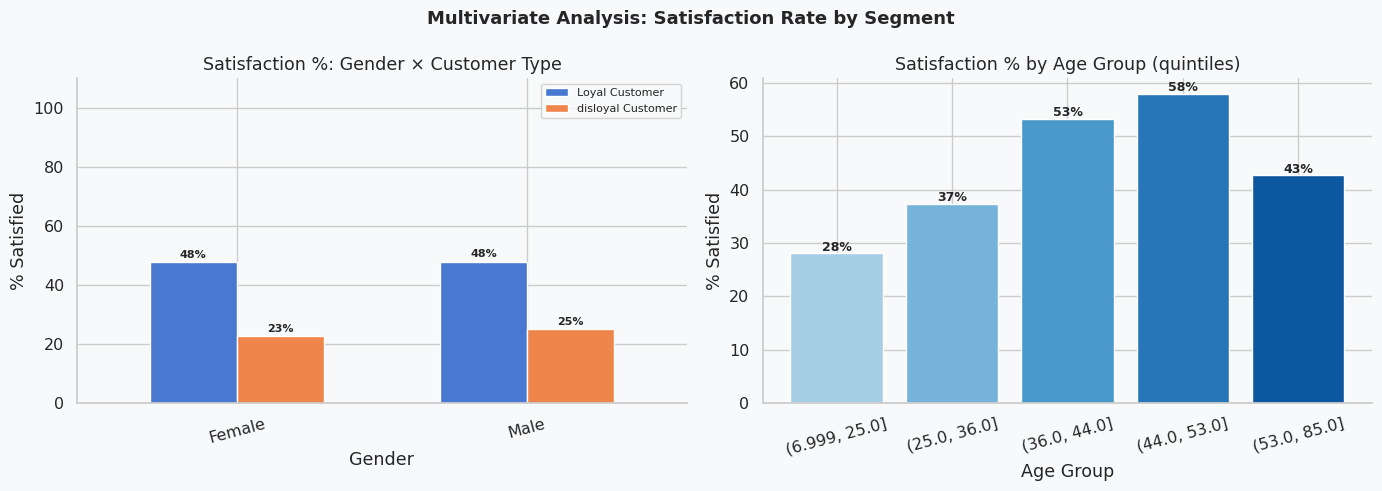


Insights:
   • Best  segment: Gender="Male" + Customer Type="Loyal Customer" → 48% satisfied
   • Worst segment: Gender="Female" + Customer Type="disloyal Customer" → 23% satisfied
   • Most satisfied age group: (44.0, 53.0] (58%)
   • Least satisfied age group: (6.999, 25.0] (28%)


In [12]:
# 1.7 Multivariate analysis
sat_label = target_labels[-1]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Multivariate Analysis: Satisfaction Rate by Segment', fontsize=13, fontweight='bold')

if len(cat_cols) >= 2:
    col_a, col_b = cat_cols[0], cat_cols[1]
    cross = df.groupby([col_a, col_b])[TARGET_COL].apply(
        lambda x: (x == sat_label).mean() * 100).reset_index()
    cross.columns = [col_a, col_b, 'Sat%']
    cross.pivot(index=col_a, columns=col_b, values='Sat%').plot(
        kind='bar', ax=axes[0], edgecolor='white', width=0.6)
    axes[0].set_title(f'Satisfaction %: {col_a} × {col_b}')
    axes[0].set_xlabel(col_a)
    axes[0].set_ylabel('% Satisfied')
    axes[0].tick_params(axis='x', rotation=15)
    axes[0].set_ylim(0, 110)
    axes[0].legend(fontsize=8)
    for p in axes[0].patches:
        if p.get_height() > 2:
            axes[0].text(p.get_x() + p.get_width()/2, p.get_height() + 1.5,
                         f'{p.get_height():.0f}%', ha='center', fontsize=8, fontweight='bold')

age_col = next((c for c in cont_cols if 'age' in c.lower()), None)
if age_col:
    df_tmp = df.copy()
    df_tmp['Age Group'] = pd.qcut(df_tmp[age_col], q=5, duplicates='drop')
    age_sat = df_tmp.groupby('Age Group')[TARGET_COL].apply(
        lambda x: (x == sat_label).mean() * 100)
    axes[1].bar(age_sat.index.astype(str), age_sat.values,
                color=plt.cm.Blues(np.linspace(0.35, 0.85, len(age_sat))), edgecolor='white')
    axes[1].set_title(f'Satisfaction % by Age Group (quintiles)')
    axes[1].set_xlabel('Age Group')
    axes[1].set_ylabel('% Satisfied')
    axes[1].tick_params(axis='x', rotation=15)
    for i, v in enumerate(age_sat.values):
        axes[1].text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nInsights:')
if len(cat_cols) >= 2:
    best  = cross.loc[cross['Sat%'].idxmax()]
    worst = cross.loc[cross['Sat%'].idxmin()]
    print(f'   • Best  segment: {col_a}="{best[col_a]}" + {col_b}="{best[col_b]}" → {best["Sat%"]:.0f}% satisfied')
    print(f'   • Worst segment: {col_a}="{worst[col_a]}" + {col_b}="{worst[col_b]}" → {worst["Sat%"]:.0f}% satisfied')
if age_col:
    print(f'   • Most satisfied age group: {age_sat.idxmax()} ({age_sat.max():.0f}%)')
    print(f'   • Least satisfied age group: {age_sat.idxmin()} ({age_sat.min():.0f}%)')

## 1.8 Outlier Treatment & Feature Engineering

In [13]:
# 1.8 Outlier treatment + feature engineering (trên df_fe riêng, không ảnh hưởng X_full)
OUTLIER_PCT = 99

df_fe = df.drop(columns=[TARGET_COL] + [c for c in DROP_COLS_CANDIDATES if c in df.columns]).copy()

print('Outlier Treatment:')
skewed_cols_eda = [c for c in cont_cols if abs(df_fe[c].skew()) > 1]
for col in skewed_cols_eda:
    cap = df_fe[col].quantile(OUTLIER_PCT / 100)
    n_out = (df_fe[col] > cap).sum()
    df_fe[col] = df_fe[col].clip(upper=cap)
    print(f'  • Capped "{col}" at P{OUTLIER_PCT}={cap:.0f} ({n_out:,} values clipped)')

print('\nImputation:')
for col in cont_cols:
    n_miss = df_fe[col].isnull().sum()
    if n_miss > 0:
        med = df_fe[col].median()
        df_fe[col].fillna(med, inplace=True)
        print(f'  • Imputed "{col}" with median={med:.2f} ({n_miss:,} rows)')

new_features = []

# Feature 1: Total Delay
if len(delay_cols) >= 2:
    df_fe['Total Delay'] = df_fe[delay_cols].sum(axis=1)
    df_fe['Is Delayed']  = (df_fe['Total Delay'] > 0).astype(int)
    new_features += ['Total Delay', 'Is Delayed']

# Feature 2: Inflight vs Ground service averages
inflight_kws = ['inflight', 'wifi', 'food', 'drink', 'entertainment', 'on-board', 'seat', 'leg', 'cleanliness']
ground_kws   = ['booking', 'boarding', 'gate', 'checkin', 'departure', 'arrival', 'baggage']

inflight_svc = [c for c in rating_cols if any(k in c.lower() for k in inflight_kws)]
ground_svc   = [c for c in rating_cols if any(k in c.lower() for k in ground_kws)]

if inflight_svc:
    df_fe['Avg Inflight Score'] = df_fe[inflight_svc].mean(axis=1)
    new_features.append('Avg Inflight Score')
if ground_svc:
    df_fe['Avg Ground Score'] = df_fe[ground_svc].mean(axis=1)
    new_features.append('Avg Ground Score')

# Feature 3: Log-transform skewed cols
for col in skewed_cols_eda:
    log_col = f'Log {col}'
    df_fe[log_col] = np.log1p(df_fe[col])
    new_features.append(log_col)

print('\nFeature Engineering:')
for feat in new_features:
    s = df_fe[feat].describe()[['min','max','mean']]
    print(f'  • {feat}: min={s["min"]:.2f}, max={s["max"]:.2f}, mean={s["mean"]:.2f}')

print(f'\ndf_fe ready: {df_fe.shape[0]:,} rows × {df_fe.shape[1]} columns')

Outlier Treatment:
  • Capped "Flight Distance" at P99=3882 (1,037 values clipped)
  • Capped "Departure Delay in Minutes" at P99=182 (1,040 values clipped)
  • Capped "Arrival Delay in Minutes" at P99=184 (1,020 values clipped)

Imputation:
  • Imputed "Arrival Delay in Minutes" with median=0.00 (310 rows)

Feature Engineering:
  • Total Delay: min=0.00, max=365.97, mean=28.23
  • Is Delayed: min=0.00, max=1.00, mean=0.54
  • Avg Inflight Score: min=0.88, max=5.00, mean=3.30
  • Avg Ground Score: min=0.50, max=5.00, mean=3.16
  • Log Flight Distance: min=3.47, max=8.26, mean=6.71
  • Log Departure Delay in Minutes: min=0.00, max=5.21, mean=1.23
  • Log Arrival Delay in Minutes: min=0.00, max=5.22, mean=1.26

df_fe ready: 103,904 rows × 29 columns


## 1.9 Mutual Information (Feature Importance — EDA)

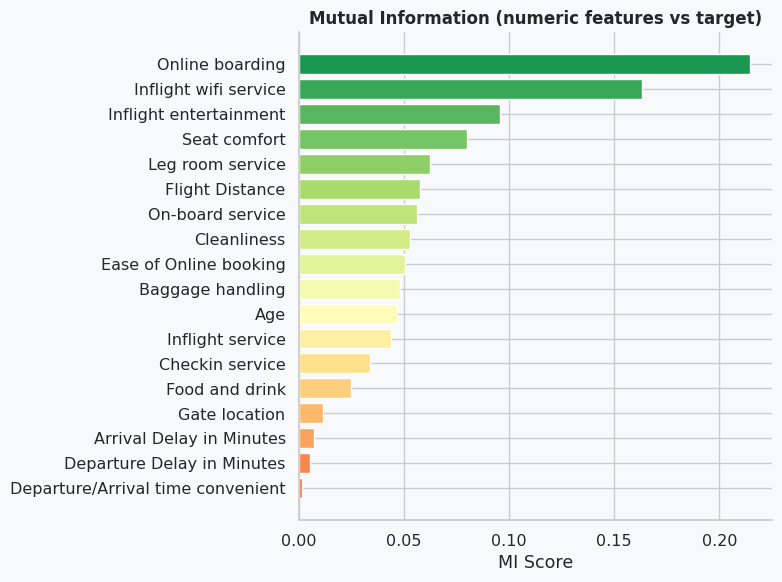


Top 5 features by MI:
   • Online boarding: 0.2145
   • Inflight wifi service: 0.1630
   • Inflight entertainment: 0.0956
   • Seat comfort: 0.0798
   • Leg room service: 0.0624


In [14]:
# 1.9 Mutual Information (supervised feature ranking trước khi train)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif

mi_sample_n = 30000 if FAST_MODE else 60000
X_mi = X_full.sample(min(mi_sample_n, len(X_full)), random_state=RANDOM_STATE)
y_mi = y_full.loc[X_mi.index]

mi_pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', SKPipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols),
], remainder='drop')

X_mi_tr = mi_pre.fit_transform(X_mi)
mi_scores = mutual_info_classif(X_mi_tr, y_mi, random_state=RANDOM_STATE)

# Only show original num features for interpretability
mi_num = pd.Series(mi_scores[:len(num_cols)], index=num_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(mi_num)))
plt.barh(mi_num.index, mi_num.values, color=colors, edgecolor='white')
plt.title('Mutual Information (numeric features vs target)', fontsize=12, fontweight='bold')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

print('\nTop 5 features by MI:')
for feat, score in mi_num.tail(5).sort_values(ascending=False).items():
    print(f'   • {feat}: {score:.4f}')

## 1.10 EDA Summary

In [15]:
# 1.10 EDA Summary
print('=' * 65)
print('  EDA SUMMARY — Airline Passenger Satisfaction')
print('=' * 65)

sat_label = target_labels[-1]
sat_pct   = (df[TARGET_COL] == sat_label).mean() * 100

tc   = corr_matrix['target_encoded'].drop('target_encoded').abs().sort_values()
_t1, _t2 = tc.index[-1], tc.index[-2]
_r1 = corr_matrix['target_encoded'][_t1]
_r2 = corr_matrix['target_encoded'][_t2]

seg_col = cat_cols[0]
seg_sat = df.groupby(seg_col)[TARGET_COL].apply(lambda x: (x == sat_label).mean() * 100)

rows = {
    'Dataset (train)'         : f'{df.shape[0]:,} rows × {df.shape[1]} columns',
    'Missing values'          : f'{df.isnull().sum().sum():,} total ({df.columns[df.isnull().any()].tolist() or ["none"]})',
    'Duplicate rows'          : str(df.duplicated().sum()),
    'Target balance'          : f'{sat_label}: {sat_pct:.1f}% / others: {100-sat_pct:.1f}%',
    'Top feature (corr)'      : f'"{_t1}" (r={_r1:+.3f})',
    '2nd feature (corr)'      : f'"{_t2}" (r={_r2:+.3f})',
    f'Best {seg_col}'         : f'"{seg_sat.idxmax()}" ({seg_sat.max():.0f}% satisfied)',
    f'Worst {seg_col}'        : f'"{seg_sat.idxmin()}" ({seg_sat.min():.0f}% satisfied)',
    'Outlier treatment'       : f'Capped {skewed_cols_eda} at P{OUTLIER_PCT}',
    'New features (EDA)'      : ', '.join(new_features) if new_features else 'none',
    'Multicollinearity'       : f'{len(high_pairs)} pair(s) |r|>0.85' if high_pairs else 'None detected',
}

for k, v in rows.items():
    print(f'  {"• " + k:<38} : {v}')

print('=' * 65)
print('\nEDA complete → proceed to Preprocessing & Model Training.')

  EDA SUMMARY — Airline Passenger Satisfaction
  • Dataset (train)                      : 103,904 rows × 25 columns
  • Missing values                       : 310 total (['Arrival Delay in Minutes'])
  • Duplicate rows                       : 0
  • Target balance                       : satisfied: 43.3% / others: 56.7%
  • Top feature (corr)                   : "Online boarding" (r=+0.504)
  • 2nd feature (corr)                   : "Inflight entertainment" (r=+0.398)
  • Best Gender                          : "Male" (44% satisfied)
  • Worst Gender                         : "Female" (43% satisfied)
  • Outlier treatment                    : Capped ['Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes'] at P99
  • New features (EDA)                   : Total Delay, Is Delayed, Avg Inflight Score, Avg Ground Score, Log Flight Distance, Log Departure Delay in Minutes, Log Arrival Delay in Minutes
  • Multicollinearity                    : 1 pair(s) |r|>0.85

EDA comp

---
# 2. Traditional ML Pipeline

Pipeline truyền thống được thiết kế **linh hoạt, cấu hình được** theo yêu cầu đề bài:
- **Scaling:** StandardScaler / MinMaxScaler / None
- **Giảm chiều:** SVD với số component cấu hình được
- **Model:** Logistic Regression, LinearSVC, KNN, RandomForest, ExtraTrees, HistGradientBoosting
- **Đánh giá:** StratifiedKFold CV với accuracy, F1, ROC-AUC

## 2.1 Configurable Preprocessing Pipeline

In [16]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD

class SafeTruncatedSVD(BaseEstimator, TransformerMixin):
    """TruncatedSVD tự động giới hạn n_components <= n_features."""
    def __init__(self, n_components=32, random_state=42):
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y=None):
        n_features = X.shape[1]
        n_comp = int(min(self.n_components, n_features))
        self.n_components_ = n_comp
        self.svd_ = TruncatedSVD(n_components=self.n_components_, random_state=self.random_state)
        self.svd_.fit(X, y)
        return self

    def transform(self, X):
        return self.svd_.transform(X)

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)


def build_preprocessor(scaler: str = 'standard') -> ColumnTransformer:
    """
    Configurable preprocessor.
    scaler: 'standard' | 'minmax' | 'none'
    """
    if scaler == 'standard':
        scaler_obj = StandardScaler()
    elif scaler == 'minmax':
        scaler_obj = MinMaxScaler(feature_range=(0, 1))
    else:
        scaler_obj = 'passthrough'

    num_pipe = SKPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler_obj),
    ])
    cat_pipe = SKPipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])

    return ColumnTransformer([
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
    ], remainder='drop', sparse_threshold=0.3)


def make_pipeline(model, scaler='standard', use_svd=False, n_components=32):
    """Factory: build complete sklearn Pipeline."""
    steps = [('preprocess', build_preprocessor(scaler=scaler))]
    if use_svd:
        steps.append(('svd', SafeTruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)))
    steps.append(('model', model))
    return SKPipeline(steps)


print('Pipeline factory ready.')
print('   Scalers available: standard, minmax, none')
print('   SVD: configurable n_components')

Pipeline factory ready.
   Scalers available: standard, minmax, none
   SVD: configurable n_components


## 2.2 Baseline (Dummy Classifier)

In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

def cv_summary(pipe, X, y, cv, scoring):
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    out = {}
    for k in scoring.keys():
        out[f'{k}_mean'] = float(np.mean(res[f'test_{k}']))
        out[f'{k}_std']  = float(np.std(res[f'test_{k}']))
    return out

n_splits = 3 if FAST_MODE else 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
scoring = {'acc': 'accuracy', 'f1': 'f1', 'roc_auc': 'roc_auc'}

print(f'Running {n_splits}-fold CV baseline...')
baseline_pipe  = make_pipeline(DummyClassifier(strategy='most_frequent'), scaler='none', use_svd=False)
baseline_stats = cv_summary(baseline_pipe, X_full, y_full, cv=cv, scoring=scoring)

print(f"  Accuracy : {baseline_stats['acc_mean']:.4f} ± {baseline_stats['acc_std']:.4f}")
print(f"  F1       : {baseline_stats['f1_mean']:.4f} ± {baseline_stats['f1_std']:.4f}")
print(f"  ROC-AUC  : {baseline_stats['roc_auc_mean']:.4f} ± {baseline_stats['roc_auc_std']:.4f}")
print('\nBaseline (most_frequent): F1=0 because no positive class predicted. Models must beat this.')

Running 5-fold CV baseline...
  Accuracy : 0.5667 ± 0.0000
  F1       : 0.0000 ± 0.0000
  ROC-AUC  : 0.5000 ± 0.0000

Baseline (most_frequent): F1=0 because no positive class predicted. Models must beat this.


**Vì sao cần baseline?**  
Baseline là “mốc sàn” để biết mô hình học máy **có thật sự học được gì** hay chỉ ăn may. Ở đây dùng:
- `DummyClassifier(strategy="most_frequent")`: luôn dự đoán **lớp xuất hiện nhiều nhất**.
- Đây là baseline mạnh nhất trong nhóm “ngây thơ” (naive) vì nó tối đa hóa accuracy trong các cách dự đoán hằng số.

**Kết quả baseline (CV trên FULL train):**
- `acc_mean ≈ 0.5667`: mô hình đoán **toàn lớp đa số**, nên accuracy xấp xỉ **tỷ lệ lớp đa số** trong dữ liệu (~56.67%).
- `f1_mean = 0.0`: do mô hình **không bao giờ dự đoán lớp 1** (mặc định F1 tính cho lớp 1), nên Precision/Recall cho lớp 1 đều bằng 0 ⇒ F1 = 0.
- `roc_auc_mean = 0.5`: tương đương **đoán ngẫu nhiên** về mặt ranking (không có khả năng phân biệt hai lớp).

**Ý nghĩa:**  
Nếu các mô hình “xịn” không vượt baseline một cách rõ rệt (đặc biệt ở F1 và ROC-AUC) thì pipeline chưa học được tín hiệu thực sự.

## 2.3 Model Zoo — CV Comparison

Đa dạng model, bao gồm cả **cấu hình scaling** và **SVD** khác nhau để thể hiện pipeline linh hoạt theo yêu cầu đề bài.

Mình chọn một tập mô hình đa dạng để bao phủ nhiều “giả định học” khác nhau:

- **Logistic Regression (LogReg)**: mô hình tuyến tính, baseline mạnh cho dữ liệu đặc trưng nhiều chiều; nhanh, dễ giải thích.
- **LinearSVC (calibrated)**: biên phân tách tuyến tính tốt; bản *calibrated* giúp có xác suất/điểm phù hợp để tính ROC-AUC và so sánh công bằng.
- **KNN**: mô hình dựa trên láng giềng, nhạy với khoảng cách; thường hiệu quả khi biểu diễn đặc trưng “tốt” và số chiều không quá cao.
- **RandomForest / ExtraTrees**: ensemble cây quyết định, bắt quan hệ phi tuyến tốt, khá robust; ExtraTrees ngẫu nhiên hơn nên đôi khi tổng quát hóa tốt.
- **HistGradientBoosting**: boosting hiệu quả cho dữ liệu tabular, thường đạt chất lượng rất cao; học phi tuyến mạnh và tối ưu tốt.

Mục tiêu là không “đánh bạc” với 1 họ mô hình, mà **so sánh công bằng nhiều họ** rồi chọn theo CV.

**Standardization (chuẩn hóa).**  
Các mô hình dựa trên khoảng cách/biên như **LogReg, SVM, KNN** nhạy với thang đo đặc trưng. Chuẩn hóa giúp:
- hội tụ ổn định hơn,
- tránh đặc trưng có biên độ lớn “lấn át” đặc trưng khác.

**SVD (giảm chiều, ví dụ SVD(32)).**  
SVD thường hữu ích khi:
- số chiều lớn (đặc biệt đặc trưng dạng sparse/one-hot/TF-IDF),
- có nhiễu/đồng tuyến tính,
- muốn tăng tốc và giảm “lời nguyền số chiều”.

Đặc biệt với **KNN**, giảm chiều giúp khoảng cách có ý nghĩa hơn và giảm chi phí tính khoảng cách.  
Với **mô hình cây (RF/ExtraTrees/HGB)**, giảm chiều thường **không cần thiết** vì cây tự chọn ngưỡng và tương tác đặc trưng theo cách khác (không dựa trên chuẩn hóa/khoảng cách).

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

models_zoo = {}

# ── Linear models (cần scaling) ───────────────────────────────────────────────
models_zoo['LogReg (StandardScaler)']  = make_pipeline(
    LogisticRegression(max_iter=3000), scaler='standard')
models_zoo['LogReg (MinMaxScaler)']    = make_pipeline(
    LogisticRegression(max_iter=3000), scaler='minmax')
models_zoo['LogReg + SVD(32)']         = make_pipeline(
    LogisticRegression(max_iter=3000), scaler='standard', use_svd=True, n_components=32)
models_zoo['LinearSVC (calibrated)']   = make_pipeline(
    CalibratedClassifierCV(LinearSVC(), method='sigmoid', cv=3), scaler='standard')

# ── Instance-based ────────────────────────────────────────────────────────────
models_zoo['KNN(k=15) + SVD(32)']      = make_pipeline(
    KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1),
    scaler='standard', use_svd=True, n_components=32)

# ── Tree ensembles (no scaling needed) ───────────────────────────────────────
n_est = 200 if FAST_MODE else 400
models_zoo['RandomForest']             = make_pipeline(
    RandomForestClassifier(n_estimators=n_est, random_state=RANDOM_STATE, n_jobs=-1), scaler='none')
models_zoo['ExtraTrees']               = make_pipeline(
    ExtraTreesClassifier(n_estimators=n_est*2, random_state=RANDOM_STATE, n_jobs=-1), scaler='none')
models_zoo['HistGradientBoosting']     = make_pipeline(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE), scaler='none')

if FAST_MODE:
    keep = ['LogReg (StandardScaler)', 'LogReg + SVD(32)', 'RandomForest', 'HistGradientBoosting', 'KNN(k=15) + SVD(32)']
    models_zoo = {k: models_zoo[k] for k in keep}

print(f'Evaluating {len(models_zoo)} models with {n_splits}-fold CV...')

zoo_rows = []
for name, pipe in models_zoo.items():
    stats = cv_summary(pipe, X_full, y_full, cv=cv, scoring=scoring)
    zoo_rows.append({'model': name, **stats})
    print(f'  ✓ {name:40s} F1={stats["f1_mean"]:.4f}±{stats["f1_std"]:.4f} AUC={stats["roc_auc_mean"]:.4f}')

zoo_df = pd.DataFrame(zoo_rows).sort_values('f1_mean', ascending=False).reset_index(drop=True)
print()
display(zoo_df)

Evaluating 8 models with 5-fold CV...
  ✓ LogReg (StandardScaler)                  F1=0.8531±0.0025 AUC=0.9267
  ✓ LogReg (MinMaxScaler)                    F1=0.8532±0.0025 AUC=0.9266
  ✓ LogReg + SVD(32)                         F1=0.8531±0.0025 AUC=0.9267
  ✓ LinearSVC (calibrated)                   F1=0.8519±0.0031 AUC=0.9261
  ✓ KNN(k=15) + SVD(32)                      F1=0.9137±0.0021 AUC=0.9794
  ✓ RandomForest                             F1=0.9564±0.0015 AUC=0.9943
  ✓ ExtraTrees                               F1=0.9543±0.0017 AUC=0.9935
  ✓ HistGradientBoosting                     F1=0.9570±0.0011 AUC=0.9949



,model,acc_mean,acc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,HistGradientBoosting,0.963399,0.000889,0.957006,0.001091,0.994861,0.000366
1,RandomForest,0.962870,0.001232,0.956449,0.001490,0.994257,0.000376
2,ExtraTrees,0.960974,0.001433,0.954262,0.001739,0.993479,0.000463
3,KNN(k=15) + SVD(32),0.928001,0.001619,0.913720,0.002071,0.979416,0.001243
4,LogReg (MinMaxScaler),0.875289,0.002148,0.853206,0.002502,0.926600,0.001873
5,LogReg (StandardScaler),0.875212,0.002185,0.853086,0.002540,0.926676,0.001891
6,LogReg + SVD(32),0.875212,0.002185,0.853086,0.002540,0.926676,0.001891
7,LinearSVC (calibrated),0.874115,0.002563,0.851853,0.003051,0.926117,0.001955


## 2.4 Model Selection Log

In [19]:
# Model selection với log rõ ràng
baseline_f1  = baseline_stats['f1_mean']
baseline_auc = baseline_stats['roc_auc_mean']

log_df = zoo_df.copy()
log_df['f1_gain_vs_baseline']  = log_df['f1_mean'] - baseline_f1
log_df['auc_gain_vs_baseline'] = log_df['roc_auc_mean'] - baseline_auc
log_df['decision'] = 'rejected'

best_name = log_df.iloc[0]['model']
log_df.loc[log_df['model'] == best_name, 'decision'] = 'SELECTED (best CV F1)'

print('=' * 60)
print('  MODEL SELECTION LOG')
print('=' * 60)
print(f'  Baseline F1  : {baseline_f1:.4f}')
print(f'  Baseline AUC : {baseline_auc:.4f}')
print()
for _, row in log_df.iterrows():
    status = 'SELECTED' if row['decision'].startswith('SELECTED') else 'rejected'
    print(f'  {status} | {row["model"]:<45} | F1={row["f1_mean"]:.4f} | ΔF1={row["f1_gain_vs_baseline"]:+.4f}')

print('=' * 60)
print(f'\nBest model: {best_name}')
display(log_df[['model', 'f1_mean', 'f1_std', 'roc_auc_mean', 'f1_gain_vs_baseline', 'decision']])

  MODEL SELECTION LOG
  Baseline F1  : 0.0000
  Baseline AUC : 0.5000

  SELECTED | HistGradientBoosting                          | F1=0.9570 | ΔF1=+0.9570
  rejected | RandomForest                                  | F1=0.9564 | ΔF1=+0.9564
  rejected | ExtraTrees                                    | F1=0.9543 | ΔF1=+0.9543
  rejected | KNN(k=15) + SVD(32)                           | F1=0.9137 | ΔF1=+0.9137
  rejected | LogReg (MinMaxScaler)                         | F1=0.8532 | ΔF1=+0.8532
  rejected | LogReg (StandardScaler)                       | F1=0.8531 | ΔF1=+0.8531
  rejected | LogReg + SVD(32)                              | F1=0.8531 | ΔF1=+0.8531
  rejected | LinearSVC (calibrated)                        | F1=0.8519 | ΔF1=+0.8519

Best model: HistGradientBoosting


,model,f1_mean,f1_std,roc_auc_mean,f1_gain_vs_baseline,decision
0,HistGradientBoosting,0.957006,0.001091,0.994861,0.957006,SELECTED (best CV F1)
1,RandomForest,0.956449,0.001490,0.994257,0.956449,rejected
2,ExtraTrees,0.954262,0.001739,0.993479,0.954262,rejected
3,KNN(k=15) + SVD(32),0.913720,0.002071,0.979416,0.913720,rejected
4,LogReg (MinMaxScaler),0.853206,0.002502,0.926600,0.853206,rejected
5,LogReg (StandardScaler),0.853086,0.002540,0.926676,0.853086,rejected
6,LogReg + SVD(32),0.853086,0.002540,0.926676,0.853086,rejected
7,LinearSVC (calibrated),0.851853,0.003051,0.926117,0.851853,rejected


## 2.5 Hyperparameter Tuning (RandomizedSearchCV)

Tuning **configurable** theo model được chọn, với các param spaces đa dạng.

In [20]:
from sklearn.model_selection import RandomizedSearchCV

selected_pipe = models_zoo[best_name]
param_distributions = {}

if 'LogReg' in best_name:
    param_distributions = {
        'model__C': np.logspace(-3, 2, 20),
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs', 'saga'],
    }
elif 'RandomForest' in best_name:
    param_distributions = {
        'model__n_estimators': [200, 400, 600],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2', None],
    }
elif 'ExtraTrees' in best_name:
    param_distributions = {
        'model__n_estimators': [300, 600, 900],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
    }
elif 'HistGradientBoosting' in best_name:
    param_distributions = {
        'model__learning_rate': [0.02, 0.05, 0.1, 0.2],
        'model__max_depth': [None, 3, 5, 7],
        'model__max_leaf_nodes': [15, 31, 63],
        'model__min_samples_leaf': [20, 50, 100],
    }
elif 'SVC' in best_name or 'LinearSVC' in best_name:
    param_distributions = {'model__base_estimator__C': np.logspace(-3, 2, 15)}
elif 'KNN' in best_name:
    param_distributions = {
        'model__n_neighbors': [5, 10, 15, 20, 30],
        'model__weights': ['uniform', 'distance'],
    }

do_tuning = (not FAST_MODE) and (len(param_distributions) > 0)
print(f'Tuning enabled: {do_tuning} | Params space size: {len(param_distributions)}')

if do_tuning:
    cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    n_iter = 20

    search = RandomizedSearchCV(
        selected_pipe,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring='f1',
        cv=cv_tune,
        n_jobs=-1,
        verbose=1,
        random_state=RANDOM_STATE
    )
    search.fit(X_full, y_full)
    print(f'\nBest params: {search.best_params_}')
    print(f'Best CV F1: {search.best_score_:.4f}')
    tuned_pipe = search.best_estimator_
else:
    tuned_pipe = selected_pipe
    print('\nSkip tuning (FAST_MODE or no param space). Using best zoo model.')

Tuning enabled: True | Params space size: 4
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params: {'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 63, 'model__max_depth': None, 'model__learning_rate': 0.1}
Best CV F1: 0.9586


## 2.6 Final Evaluation on Test Set

  TRADITIONAL ML — Test Set Metrics
  Model     : HistGradientBoosting
  Accuracy  : 0.9644
  Precision : 0.9755
  Recall    : 0.9426
  F1        : 0.9588
  ROC-AUC   : 0.9956

Classification Report:
              precision    recall  f1-score   support

           0     0.9563    0.9815    0.9687     14573
           1     0.9755    0.9426    0.9588     11403

    accuracy                         0.9644     25976
   macro avg     0.9659    0.9621    0.9638     25976
weighted avg     0.9647    0.9644    0.9644     25976



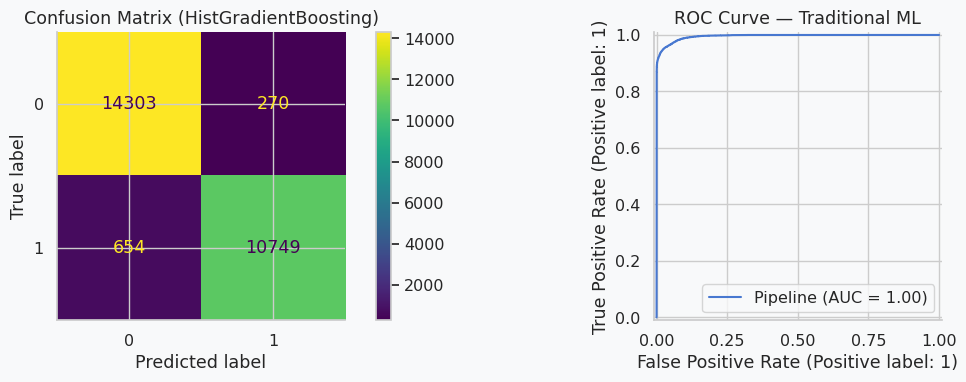

In [21]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# Train on full training set
tuned_pipe.fit(X_full, y_full)
test_pred_trad = tuned_pipe.predict(X_test)

print('=' * 55)
print('  TRADITIONAL ML — Test Set Metrics')
print('=' * 55)
print(f'  Model     : {best_name}')
print(f'  Accuracy  : {accuracy_score(y_test, test_pred_trad):.4f}')
print(f'  Precision : {precision_score(y_test, test_pred_trad):.4f}')
print(f'  Recall    : {recall_score(y_test, test_pred_trad):.4f}')
print(f'  F1        : {f1_score(y_test, test_pred_trad):.4f}')

trad_auc = None
if hasattr(tuned_pipe, 'predict_proba'):
    test_proba_trad = tuned_pipe.predict_proba(X_test)[:, 1]
    trad_auc = roc_auc_score(y_test, test_proba_trad)
elif hasattr(tuned_pipe, 'decision_function'):
    test_score_trad = tuned_pipe.decision_function(X_test)
    trad_auc = roc_auc_score(y_test, test_score_trad)
if trad_auc is not None:
    print(f'  ROC-AUC   : {trad_auc:.4f}')
print('=' * 55)

print('\nClassification Report:')
print(classification_report(y_test, test_pred_trad, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_test, test_pred_trad)
ConfusionMatrixDisplay(cm).plot(ax=axes[0], values_format='d')
axes[0].set_title(f'Confusion Matrix ({best_name})')

try:
    RocCurveDisplay.from_estimator(tuned_pipe, X_test, y_test, ax=axes[1])
    axes[1].set_title('ROC Curve — Traditional ML')
except Exception:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()

## 2.7 Save Artifacts & Features

In [22]:
import joblib
from scipy import sparse

# Save model
model_path = ARTIFACTS_DIR / 'best_pipeline.joblib'
joblib.dump(tuned_pipe, model_path)
print(f'Saved model: {model_path}')

# Save EDA/selection tables
zoo_df.to_csv(EDA_DIR / 'model_zoo_results.csv', index=False)
log_df.to_csv(EDA_DIR / 'model_selection_log.csv', index=False)
print(f'Saved EDA tables to {EDA_DIR}')

# Save extracted features (.npy or .npz)
pre = tuned_pipe.named_steps['preprocess']
Xtr_feat = pre.transform(X_full)
Xte_feat = pre.transform(X_test)

if sparse.issparse(Xtr_feat):
    sparse.save_npz(FEATURES_DIR / 'train_features.npz', Xtr_feat)
    sparse.save_npz(FEATURES_DIR / 'test_features.npz',  Xte_feat)
    print(f'Saved features (.npz sparse) to {FEATURES_DIR}')
else:
    np.save(FEATURES_DIR / 'train_features.npy', Xtr_feat)
    np.save(FEATURES_DIR / 'test_features.npy',  Xte_feat)
    print(f'Saved features (.npy) to {FEATURES_DIR}')

try:
    feat_names = pre.get_feature_names_out().tolist()
except Exception:
    feat_names = None
with open(FEATURES_DIR / 'feature_names.json', 'w') as f:
    json.dump(feat_names, f, indent=2)
print(f'Saved feature_names.json')

Saved model: outputs/artifacts/best_pipeline.joblib
Saved EDA tables to outputs/eda_outputs
Saved features (.npy) to outputs/features
Saved feature_names.json


---
# 3. Deep Learning Pipeline (Tabular Neural Networks)

**Mục đích:** So sánh với pipeline truyền thống → cộng điểm thưởng theo đề bài.

**Kiến trúc thử nghiệm:**
- Model A: MLP (baseline neural)
- Model B: MLP + BatchNorm + Dropout
- Model C: ResMLP (Residual connections)
- Model D: Wide & Deep
- Model E: TabNetLite (Feature Gating)
- Model F: FT-Transformer (Feature-Token Transformer)

**Feature pipeline:** One-Hot → TruncatedSVD (dim reduction) → StandardScaler → Dense vector cho NN

## 3.0 Setup (PyTorch + Utilities)

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split as sk_split
from scipy import sparse as sp_sparse

def seed_torch(seed=RANDOM_STATE):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_torch(RANDOM_STATE)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE:', DEVICE)

# Hyperparams
DL_SVD  = 64 if FAST_MODE else 128
DL_BATCH   = 2048 if FAST_MODE else 1024
DL_EPOCHS  = 8  if FAST_MODE else 25
DL_PATIENCE = 3 if FAST_MODE else 6
DL_LR  = 1e-3
DL_WD  = 1e-5

print(f'DL config: SVD={DL_SVD}, Batch={DL_BATCH}, Epochs={DL_EPOCHS}')

DEVICE: cuda
DL config: SVD=128, Batch=1024, Epochs=25


## 3.1 DL Feature Pipeline (One-Hot → SVD → Scale)

In [24]:
# Build DL feature pipe: One-Hot → TruncatedSVD → StandardScaler
dl_preprocess = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', SKPipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols),
], remainder='drop')

# Train/val split for early stopping
X_tr_df, X_val_df, y_tr, y_val = sk_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=RANDOM_STATE)

Xt_tmp = dl_preprocess.fit_transform(X_tr_df, y_tr)
n_feat = Xt_tmp.shape[1]
print(f'n_features after One-Hot: {n_feat}')

svd_k = int(min(DL_SVD, n_feat - 1)) if DL_SVD and DL_SVD < n_feat else None
use_svd_dl = svd_k is not None
print(f'SVD: {"enabled, k=" + str(svd_k) if use_svd_dl else "disabled"}')

svd_step    = TruncatedSVD(n_components=svd_k, random_state=RANDOM_STATE) if use_svd_dl else 'passthrough'
scaler_step = StandardScaler(with_mean=False) if (not use_svd_dl and sp_sparse.issparse(Xt_tmp)) else StandardScaler()

dl_feat_pipe = SKPipeline([
    ('preprocess', dl_preprocess),
    ('svd', svd_step),
    ('scaler', scaler_step),
])

dl_feat_pipe.fit(X_tr_df, y_tr)

X_tr  = dl_feat_pipe.transform(X_tr_df).astype(np.float32)
X_val = dl_feat_pipe.transform(X_val_df).astype(np.float32)
X_te  = dl_feat_pipe.transform(X_test).astype(np.float32)

y_tr_np  = y_tr.to_numpy().astype(np.float32)
y_val_np = y_val.to_numpy().astype(np.float32)
y_te_np  = y_test.to_numpy().astype(np.float32)

INPUT_DIM = X_tr.shape[1]
print(f'DL INPUT_DIM: {INPUT_DIM} | train/val/test: {X_tr.shape} {X_val.shape} {X_te.shape}')

class TabDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).view(-1, 1)
    def __len__(self):   return self.X.shape[0]
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TabDataset(X_tr,  y_tr_np),  batch_size=DL_BATCH, shuffle=True)
val_loader   = DataLoader(TabDataset(X_val, y_val_np), batch_size=DL_BATCH, shuffle=False)
test_loader  = DataLoader(TabDataset(X_te,  y_te_np),  batch_size=DL_BATCH, shuffle=False)

def eval_metrics(y_true, logits):
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    return {
        'acc':     float(accuracy_score(y_true, preds)),
        'f1':      float(f1_score(y_true, preds)),
        'roc_auc': float(roc_auc_score(y_true, probs)),
    }

@torch.no_grad()
def predict_logits(model, loader, device=DEVICE):
    model.eval()
    all_logits, all_y = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        all_logits.append(model(xb).detach().cpu().numpy().reshape(-1))
        all_y.append(yb.numpy().reshape(-1))
    return np.concatenate(all_y), np.concatenate(all_logits)

def train_model(model, train_loader, val_loader, epochs=DL_EPOCHS, lr=DL_LR, wd=DL_WD, patience=DL_PATIENCE, device=DEVICE):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best_f1, best_state, bad = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            nn.BCEWithLogitsLoss()(model(xb), yb).backward()
            optimizer.step()
        yv, lv = predict_logits(model, val_loader, device)
        m = eval_metrics(yv.astype(int), lv)
        if m['f1'] > best_f1 + 1e-6:
            best_f1 = m['f1']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
        print(f'  ep {ep:02d} | val_f1={m["f1"]:.4f} val_auc={m["roc_auc"]:.4f} | patience {bad}/{patience}')
        if bad >= patience:
            break
    if best_state: model.load_state_dict(best_state)
    return model

dl_results = {}
dl_models  = {}
print('DL utilities ready.')

n_features after One-Hot: 27
SVD: disabled
DL INPUT_DIM: 27 | train/val/test: (83123, 27) (20781, 27) (25976, 27)
DL utilities ready.


## 3.2 Model A — MLP (Baseline Neural)

In [25]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden1=256, hidden2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.ReLU(),
            nn.Linear(hidden1, hidden2), nn.ReLU(),
            nn.Linear(hidden2, 1),
        )
    def forward(self, x): return self.net(x)

print('Training MLP...')
m_mlp = train_model(MLP(INPUT_DIM), train_loader, val_loader)
yv, lv = predict_logits(m_mlp, val_loader)
yt, lt = predict_logits(m_mlp, test_loader)
dl_results['MLP'] = {'val': eval_metrics(yv.astype(int), lv), 'test': eval_metrics(yt.astype(int), lt)}
dl_models['MLP'] = m_mlp
print('MLP test F1:', dl_results['MLP']['test']['f1'])

Training MLP...
  ep 01 | val_f1=0.8993 val_auc=0.9701 | patience 0/6
  ep 02 | val_f1=0.9221 val_auc=0.9829 | patience 0/6
  ep 03 | val_f1=0.9322 val_auc=0.9862 | patience 0/6
  ep 04 | val_f1=0.9319 val_auc=0.9885 | patience 1/6
  ep 05 | val_f1=0.9371 val_auc=0.9895 | patience 0/6
  ep 06 | val_f1=0.9412 val_auc=0.9906 | patience 0/6
  ep 07 | val_f1=0.9458 val_auc=0.9914 | patience 0/6
  ep 08 | val_f1=0.9385 val_auc=0.9917 | patience 1/6
  ep 09 | val_f1=0.9459 val_auc=0.9921 | patience 0/6
  ep 10 | val_f1=0.9490 val_auc=0.9927 | patience 0/6
  ep 11 | val_f1=0.9472 val_auc=0.9929 | patience 1/6
  ep 12 | val_f1=0.9454 val_auc=0.9927 | patience 2/6
  ep 13 | val_f1=0.9489 val_auc=0.9927 | patience 3/6
  ep 14 | val_f1=0.9473 val_auc=0.9929 | patience 4/6
  ep 15 | val_f1=0.9491 val_auc=0.9931 | patience 0/6
  ep 16 | val_f1=0.9467 val_auc=0.9933 | patience 1/6
  ep 17 | val_f1=0.9483 val_auc=0.9935 | patience 2/6
  ep 18 | val_f1=0.9501 val_auc=0.9935 | patience 0/6
  ep 19 | va

## 3.3 Model B — MLP + BatchNorm + Dropout

In [26]:
class MLP_BN(nn.Module):
    def __init__(self, input_dim, hidden=256, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden),   nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x): return self.net(x)

print('Training MLP_BN...')
m_bn = train_model(MLP_BN(INPUT_DIM), train_loader, val_loader)
yv, lv = predict_logits(m_bn, val_loader)
yt, lt = predict_logits(m_bn, test_loader)
dl_results['MLP_BN'] = {'val': eval_metrics(yv.astype(int), lv), 'test': eval_metrics(yt.astype(int), lt)}
dl_models['MLP_BN'] = m_bn
print('MLP_BN test F1:', dl_results['MLP_BN']['test']['f1'])

Training MLP_BN...
  ep 01 | val_f1=0.9170 val_auc=0.9800 | patience 0/6
  ep 02 | val_f1=0.9254 val_auc=0.9857 | patience 0/6
  ep 03 | val_f1=0.9364 val_auc=0.9882 | patience 0/6
  ep 04 | val_f1=0.9408 val_auc=0.9900 | patience 0/6
  ep 05 | val_f1=0.9445 val_auc=0.9911 | patience 0/6
  ep 06 | val_f1=0.9470 val_auc=0.9918 | patience 0/6
  ep 07 | val_f1=0.9504 val_auc=0.9923 | patience 0/6
  ep 08 | val_f1=0.9484 val_auc=0.9925 | patience 1/6
  ep 09 | val_f1=0.9504 val_auc=0.9931 | patience 2/6
  ep 10 | val_f1=0.9510 val_auc=0.9932 | patience 0/6
  ep 11 | val_f1=0.9512 val_auc=0.9935 | patience 0/6
  ep 12 | val_f1=0.9517 val_auc=0.9937 | patience 0/6
  ep 13 | val_f1=0.9523 val_auc=0.9937 | patience 0/6
  ep 14 | val_f1=0.9526 val_auc=0.9939 | patience 0/6
  ep 15 | val_f1=0.9521 val_auc=0.9941 | patience 1/6
  ep 16 | val_f1=0.9530 val_auc=0.9941 | patience 0/6
  ep 17 | val_f1=0.9539 val_auc=0.9942 | patience 0/6
  ep 18 | val_f1=0.9525 val_auc=0.9942 | patience 1/6
  ep 19 |

## 3.4 Model C — ResMLP (Residual Connections)

In [27]:
class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim); self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout); self.fc2 = nn.Linear(dim, dim)
    def forward(self, x):
        return x + self.fc2(self.drop(self.act(self.fc1(x))))

class ResMLP(nn.Module):
    def __init__(self, input_dim, hidden=256, n_blocks=3, dropout=0.2):
        super().__init__()
        self.inp = nn.Sequential(nn.Linear(input_dim, hidden), nn.ReLU())
        self.blocks = nn.Sequential(*[ResBlock(hidden, dropout) for _ in range(n_blocks)])
        self.out = nn.Linear(hidden, 1)
    def forward(self, x): return self.out(self.blocks(self.inp(x)))

print('Training ResMLP...')
m_res = train_model(ResMLP(INPUT_DIM), train_loader, val_loader)
yv, lv = predict_logits(m_res, val_loader)
yt, lt = predict_logits(m_res, test_loader)
dl_results['ResMLP'] = {'val': eval_metrics(yv.astype(int), lv), 'test': eval_metrics(yt.astype(int), lt)}
dl_models['ResMLP'] = m_res
print('ResMLP test F1:', dl_results['ResMLP']['test']['f1'])

Training ResMLP...
  ep 01 | val_f1=0.9291 val_auc=0.9856 | patience 0/6
  ep 02 | val_f1=0.9361 val_auc=0.9913 | patience 0/6
  ep 03 | val_f1=0.9480 val_auc=0.9927 | patience 0/6
  ep 04 | val_f1=0.9492 val_auc=0.9933 | patience 0/6
  ep 05 | val_f1=0.9502 val_auc=0.9937 | patience 0/6
  ep 06 | val_f1=0.9524 val_auc=0.9942 | patience 0/6
  ep 07 | val_f1=0.9535 val_auc=0.9943 | patience 0/6
  ep 08 | val_f1=0.9517 val_auc=0.9941 | patience 1/6
  ep 09 | val_f1=0.9519 val_auc=0.9939 | patience 2/6
  ep 10 | val_f1=0.9549 val_auc=0.9943 | patience 0/6
  ep 11 | val_f1=0.9549 val_auc=0.9940 | patience 0/6
  ep 12 | val_f1=0.9524 val_auc=0.9940 | patience 1/6
  ep 13 | val_f1=0.9539 val_auc=0.9944 | patience 2/6
  ep 14 | val_f1=0.9571 val_auc=0.9944 | patience 0/6
  ep 15 | val_f1=0.9554 val_auc=0.9945 | patience 1/6
  ep 16 | val_f1=0.9553 val_auc=0.9945 | patience 2/6
  ep 17 | val_f1=0.9535 val_auc=0.9944 | patience 3/6
  ep 18 | val_f1=0.9569 val_auc=0.9944 | patience 4/6
  ep 19 |

## 3.5 Model D — Wide & Deep

In [28]:
class WideDeep(nn.Module):
    def __init__(self, input_dim, deep_hidden=256, dropout=0.25):
        super().__init__()
        self.wide = nn.Linear(input_dim, 1)
        self.deep = nn.Sequential(
            nn.Linear(input_dim, deep_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(deep_hidden, deep_hidden//2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(deep_hidden//2, 1),
        )
    def forward(self, x): return self.wide(x) + self.deep(x)

print('Training WideDeep...')
m_wd = train_model(WideDeep(INPUT_DIM), train_loader, val_loader)
yv, lv = predict_logits(m_wd, val_loader)
yt, lt = predict_logits(m_wd, test_loader)
dl_results['WideDeep'] = {'val': eval_metrics(yv.astype(int), lv), 'test': eval_metrics(yt.astype(int), lt)}
dl_models['WideDeep'] = m_wd
print('WideDeep test F1:', dl_results['WideDeep']['test']['f1'])

Training WideDeep...
  ep 01 | val_f1=0.8977 val_auc=0.9677 | patience 0/6
  ep 02 | val_f1=0.9188 val_auc=0.9808 | patience 0/6
  ep 03 | val_f1=0.9280 val_auc=0.9854 | patience 0/6
  ep 04 | val_f1=0.9342 val_auc=0.9875 | patience 0/6
  ep 05 | val_f1=0.9384 val_auc=0.9889 | patience 0/6
  ep 06 | val_f1=0.9396 val_auc=0.9902 | patience 0/6
  ep 07 | val_f1=0.9427 val_auc=0.9909 | patience 0/6
  ep 08 | val_f1=0.9454 val_auc=0.9915 | patience 0/6
  ep 09 | val_f1=0.9472 val_auc=0.9918 | patience 0/6
  ep 10 | val_f1=0.9480 val_auc=0.9925 | patience 0/6
  ep 11 | val_f1=0.9450 val_auc=0.9924 | patience 1/6
  ep 12 | val_f1=0.9480 val_auc=0.9927 | patience 2/6
  ep 13 | val_f1=0.9500 val_auc=0.9930 | patience 0/6
  ep 14 | val_f1=0.9500 val_auc=0.9932 | patience 0/6
  ep 15 | val_f1=0.9515 val_auc=0.9935 | patience 0/6
  ep 16 | val_f1=0.9520 val_auc=0.9936 | patience 0/6
  ep 17 | val_f1=0.9509 val_auc=0.9938 | patience 1/6
  ep 18 | val_f1=0.9507 val_auc=0.9939 | patience 2/6
  ep 19

## 3.6 Model E — TabNetLite (Feature Gating)

In [29]:
class TabNetLite(nn.Module):
    def __init__(self, input_dim, hidden=256, n_steps=3, dropout=0.2):
        super().__init__()
        self.n_steps = n_steps
        self.gates = nn.ModuleList([
            nn.Sequential(nn.Linear(input_dim, input_dim), nn.Sigmoid()) for _ in range(n_steps)])
        self.mlps  = nn.ModuleList([nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden//2, 1)) for _ in range(n_steps)])
    def forward(self, x):
        out = 0.0
        for gate, mlp in zip(self.gates, self.mlps):
            out = out + mlp(x * gate(x))
        return out / self.n_steps

print('Training TabNetLite...')
m_tnl = train_model(TabNetLite(INPUT_DIM, hidden=192 if FAST_MODE else 256), train_loader, val_loader)
yv, lv = predict_logits(m_tnl, val_loader)
yt, lt = predict_logits(m_tnl, test_loader)
dl_results['TabNetLite'] = {'val': eval_metrics(yv.astype(int), lv), 'test': eval_metrics(yt.astype(int), lt)}
dl_models['TabNetLite'] = m_tnl
print('TabNetLite test F1:', dl_results['TabNetLite']['test']['f1'])

Training TabNetLite...
  ep 01 | val_f1=0.8969 val_auc=0.9625 | patience 0/6
  ep 02 | val_f1=0.9166 val_auc=0.9806 | patience 0/6
  ep 03 | val_f1=0.9295 val_auc=0.9859 | patience 0/6
  ep 04 | val_f1=0.9378 val_auc=0.9890 | patience 0/6
  ep 05 | val_f1=0.9443 val_auc=0.9908 | patience 0/6
  ep 06 | val_f1=0.9476 val_auc=0.9920 | patience 0/6
  ep 07 | val_f1=0.9494 val_auc=0.9926 | patience 0/6
  ep 08 | val_f1=0.9497 val_auc=0.9930 | patience 0/6
  ep 09 | val_f1=0.9494 val_auc=0.9930 | patience 1/6
  ep 10 | val_f1=0.9528 val_auc=0.9936 | patience 0/6
  ep 11 | val_f1=0.9526 val_auc=0.9937 | patience 1/6
  ep 12 | val_f1=0.9526 val_auc=0.9938 | patience 2/6
  ep 13 | val_f1=0.9541 val_auc=0.9941 | patience 0/6
  ep 14 | val_f1=0.9515 val_auc=0.9942 | patience 1/6
  ep 15 | val_f1=0.9549 val_auc=0.9942 | patience 0/6
  ep 16 | val_f1=0.9554 val_auc=0.9944 | patience 0/6
  ep 17 | val_f1=0.9553 val_auc=0.9944 | patience 1/6
  ep 18 | val_f1=0.9563 val_auc=0.9946 | patience 0/6
  ep 

## 3.7 Model F — FT-Transformer (Feature-Token Transformer)

In [30]:
class FTTransformer(nn.Module):
    def __init__(self, n_features, d_model=96, n_heads=8, n_layers=3, dropout=0.1, ff_mult=4):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        self.bias   = nn.Parameter(torch.zeros(n_features, d_model))
        self.cls    = nn.Parameter(torch.zeros(1, 1, d_model))
        enc = nn.TransformerEncoderLayer(d_model, n_heads, d_model*ff_mult, dropout,
                                          activation='gelu', batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 1))
    def forward(self, x):
        tok = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)
        h   = torch.cat([self.cls.expand(x.size(0), -1, -1), tok], dim=1)
        return self.head(self.encoder(h)[:, 0, :])

ft_cfg = dict(d_model=64 if FAST_MODE else 96, n_heads=8,
              n_layers=2 if FAST_MODE else 3, dropout=0.1, ff_mult=4)

print('Training FTTransformer...')
m_ft = train_model(FTTransformer(INPUT_DIM, **ft_cfg), train_loader, val_loader, lr=8e-4)
yv, lv = predict_logits(m_ft, val_loader)
yt, lt = predict_logits(m_ft, test_loader)
dl_results['FTTransformer'] = {'val': eval_metrics(yv.astype(int), lv), 'test': eval_metrics(yt.astype(int), lt)}
dl_models['FTTransformer'] = m_ft
print('FTTransformer test F1:', dl_results['FTTransformer']['test']['f1'])

Training FTTransformer...
  ep 01 | val_f1=0.9114 val_auc=0.9792 | patience 0/6
  ep 02 | val_f1=0.9303 val_auc=0.9890 | patience 0/6
  ep 03 | val_f1=0.9488 val_auc=0.9933 | patience 0/6
  ep 04 | val_f1=0.9475 val_auc=0.9930 | patience 1/6
  ep 05 | val_f1=0.9527 val_auc=0.9941 | patience 0/6
  ep 06 | val_f1=0.9532 val_auc=0.9942 | patience 0/6
  ep 07 | val_f1=0.9551 val_auc=0.9945 | patience 0/6
  ep 08 | val_f1=0.9551 val_auc=0.9947 | patience 1/6
  ep 09 | val_f1=0.9451 val_auc=0.9920 | patience 2/6
  ep 10 | val_f1=0.9533 val_auc=0.9943 | patience 3/6
  ep 11 | val_f1=0.9577 val_auc=0.9950 | patience 0/6
  ep 12 | val_f1=0.9572 val_auc=0.9949 | patience 1/6
  ep 13 | val_f1=0.9555 val_auc=0.9949 | patience 2/6
  ep 14 | val_f1=0.9560 val_auc=0.9947 | patience 3/6
  ep 15 | val_f1=0.9581 val_auc=0.9955 | patience 0/6
  ep 16 | val_f1=0.9586 val_auc=0.9952 | patience 0/6
  ep 17 | val_f1=0.9556 val_auc=0.9951 | patience 1/6
  ep 18 | val_f1=0.9596 val_auc=0.9953 | patience 0/6
  

## 3.8 DL Model Comparison & Selection

Selected DL model (by val F1): FTTransformer


,model,val_f1,val_auc,val_acc,test_f1,test_auc,test_acc,rank,decision
0,FTTransformer,0.959573,0.995286,0.965401,0.959644,0.995292,0.965083,1,SELECTED
1,ResMLP,0.957093,0.994360,0.963236,0.957522,0.994531,0.963197,2,rejected
2,TabNetLite,0.956878,0.994860,0.963043,0.955409,0.994703,0.961349,3,rejected
3,MLP_BN,0.955713,0.994642,0.961985,0.955461,0.994538,0.961349,4,rejected
4,WideDeep,0.954895,0.994491,0.961359,0.954525,0.994292,0.960579,5,rejected
5,MLP,0.952585,0.993975,0.959482,0.953842,0.993729,0.960040,6,rejected


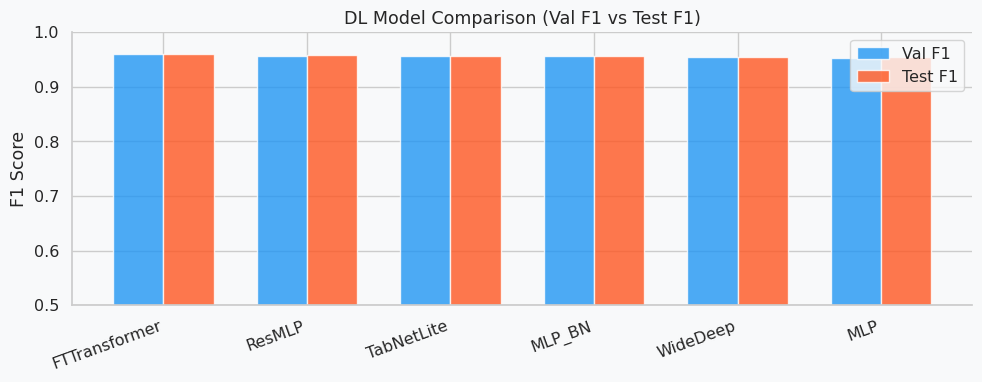

In [31]:
dl_rows = []
for name, d in dl_results.items():
    dl_rows.append({'model': name,
                    'val_f1': d['val']['f1'], 'val_auc': d['val']['roc_auc'], 'val_acc': d['val']['acc'],
                    'test_f1': d['test']['f1'], 'test_auc': d['test']['roc_auc'], 'test_acc': d['test']['acc']})

dl_table = pd.DataFrame(dl_rows).sort_values(['val_f1', 'val_auc'], ascending=False).reset_index(drop=True)
dl_table['rank'] = dl_table.index + 1
dl_table['decision'] = ['SELECTED'] + ['rejected'] * (len(dl_table) - 1)

best_dl_name = dl_table.loc[0, 'model']
print(f'Selected DL model (by val F1): {best_dl_name}')
display(dl_table)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(dl_table))
w = 0.35
ax.bar(x - w/2, dl_table['val_f1'],  w, label='Val F1',  color=PALETTE[0], alpha=0.8)
ax.bar(x + w/2, dl_table['test_f1'], w, label='Test F1', color=PALETTE[1], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(dl_table['model'], rotation=20, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('F1 Score')
ax.set_title('DL Model Comparison (Val F1 vs Test F1)')
ax.legend()
plt.tight_layout()
plt.show()

## 3.9 Retrain Best DL on Full Train → Evaluate Test → Save

In [32]:
# Refit feature pipe on FULL train
dl_preprocess_full = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', SKPipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols),
], remainder='drop')

Xt_full_tmp = dl_preprocess_full.fit_transform(X_full, y_full)
n_feat_full = Xt_full_tmp.shape[1]
svd_k_full  = int(min(DL_SVD, n_feat_full - 1)) if DL_SVD and DL_SVD < n_feat_full else None
use_svd_full = svd_k_full is not None
svd_full_step    = TruncatedSVD(n_components=svd_k_full, random_state=RANDOM_STATE) if use_svd_full else 'passthrough'
scaler_full_step = StandardScaler(with_mean=False) if (not use_svd_full and sp_sparse.issparse(Xt_full_tmp)) else StandardScaler()

dl_feat_pipe_full = SKPipeline([
    ('preprocess', dl_preprocess_full),
    ('svd', svd_full_step),
    ('scaler', scaler_full_step),
])
dl_feat_pipe_full.fit(X_full, y_full)

X_full_dl = dl_feat_pipe_full.transform(X_full).astype(np.float32)
X_test_dl = dl_feat_pipe_full.transform(X_test).astype(np.float32)
y_full_dl = y_full.to_numpy().astype(np.float32)
y_test_dl = y_test.to_numpy().astype(np.float32)

Xtr2, Xva2, ytr2, yva2 = sk_split(X_full_dl, y_full_dl, test_size=0.15,
                                    stratify=y_full_dl, random_state=RANDOM_STATE)
tl2 = DataLoader(TabDataset(Xtr2, ytr2), batch_size=DL_BATCH, shuffle=True)
vl2 = DataLoader(TabDataset(Xva2, yva2), batch_size=DL_BATCH, shuffle=False)
tel2 = DataLoader(TabDataset(X_test_dl, y_test_dl), batch_size=DL_BATCH, shuffle=False)

def build_dl_model(name, input_dim):
    if name == 'MLP':        return MLP(input_dim)
    if name == 'MLP_BN':     return MLP_BN(input_dim)
    if name == 'ResMLP':     return ResMLP(input_dim, 256, 3, 0.2)
    if name == 'WideDeep':   return WideDeep(input_dim, 256, 0.25)
    if name == 'TabNetLite': return TabNetLite(input_dim, 192 if FAST_MODE else 256)
    if name == 'FTTransformer': return FTTransformer(input_dim, **ft_cfg)
    raise ValueError(name)

best_dl_model = build_dl_model(best_dl_name, X_full_dl.shape[1])
best_dl_model = train_model(best_dl_model, tl2, vl2)

y_te_true_dl, te_logits_dl = predict_logits(best_dl_model, tel2)
dl_test_final = eval_metrics(y_te_true_dl.astype(int), te_logits_dl)
print('DL TEST metrics:', dl_test_final)

# Save DL artifacts
dl_dir = OUT_DIR / 'deep_learning'
dl_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(dl_feat_pipe_full, dl_dir / 'dl_feature_pipe.joblib')
torch.save(best_dl_model.state_dict(), dl_dir / 'best_dl_model.pt')
with open(dl_dir / 'best_dl_meta.json', 'w') as f:
    json.dump({'best_dl_name': best_dl_name, 'input_dim': int(X_full_dl.shape[1]),
               'svd_k': svd_k_full, 'threshold': 0.5}, f, indent=2)

# Save DL test features (.npy)
np.save(FEATURES_DIR / 'dl_train_features.npy', X_full_dl)
np.save(FEATURES_DIR / 'dl_test_features.npy',  X_test_dl)

# Save predictions
probs_dl = 1 / (1 + np.exp(-te_logits_dl))
preds_dl = (probs_dl >= 0.5).astype(int)
pd.DataFrame({'y_true': y_te_true_dl.astype(int), 'y_pred': preds_dl, 'y_prob': probs_dl}
             ).to_csv(dl_dir / 'dl_test_predictions.csv', index=False)

print(f'Saved DL artifacts to {dl_dir}')

  ep 01 | val_f1=0.9153 val_auc=0.9791 | patience 0/6
  ep 02 | val_f1=0.9316 val_auc=0.9877 | patience 0/6
  ep 03 | val_f1=0.9377 val_auc=0.9894 | patience 0/6
  ep 04 | val_f1=0.9499 val_auc=0.9932 | patience 0/6
  ep 05 | val_f1=0.9529 val_auc=0.9942 | patience 0/6
  ep 06 | val_f1=0.9536 val_auc=0.9944 | patience 0/6
  ep 07 | val_f1=0.9563 val_auc=0.9948 | patience 0/6
  ep 08 | val_f1=0.9559 val_auc=0.9947 | patience 1/6
  ep 09 | val_f1=0.9577 val_auc=0.9949 | patience 0/6
  ep 10 | val_f1=0.9579 val_auc=0.9951 | patience 0/6
  ep 11 | val_f1=0.9581 val_auc=0.9953 | patience 0/6
  ep 12 | val_f1=0.9585 val_auc=0.9950 | patience 0/6
  ep 13 | val_f1=0.9586 val_auc=0.9953 | patience 0/6
  ep 14 | val_f1=0.9547 val_auc=0.9940 | patience 1/6
  ep 15 | val_f1=0.9582 val_auc=0.9951 | patience 2/6
  ep 16 | val_f1=0.9592 val_auc=0.9954 | patience 0/6
  ep 17 | val_f1=0.9581 val_auc=0.9953 | patience 1/6
  ep 18 | val_f1=0.9596 val_auc=0.9953 | patience 0/6
  ep 19 | val_f1=0.9591 val_

---
# 4. Reload & Reproduce (After Kernel Reset)

Phần này cho phép **load lại model đã train** và chạy evaluation mà không cần train lại.  
**Chạy cell 4.0 trước** để định nghĩa lại custom classes, sau đó chạy 4.1 và 4.2.

## 4.0 Prerequisites

In [33]:
# 4.0) Prerequisites — chạy sau khi reset kernel

import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy import sparse

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# Re-define custom transformer (needed to unpickle .joblib)
class SafeTruncatedSVD(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=32, random_state=42):
        self.n_components = n_components
        self.random_state = random_state
    def fit(self, X, y=None):
        n_comp = int(min(self.n_components, X.shape[1]))
        self.svd_ = TruncatedSVD(n_components=n_comp, random_state=self.random_state)
        self.svd_.fit(X)
        return self
    def transform(self, X): return self.svd_.transform(X)

# Re-define DL models (needed to load .pt weights)
class MLP(nn.Module):
    def __init__(self, input_dim, hidden1=256, hidden2=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, hidden1), nn.ReLU(),
                                  nn.Linear(hidden1, hidden2), nn.ReLU(), nn.Linear(hidden2, 1))
    def forward(self, x): return self.net(x)

class MLP_BN(nn.Module):
    def __init__(self, input_dim, hidden=256, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout),
                                  nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout),
                                  nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x)

class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.fc1, self.act, self.drop, self.fc2 = nn.Linear(dim,dim), nn.ReLU(), nn.Dropout(dropout), nn.Linear(dim,dim)
    def forward(self, x): return x + self.fc2(self.drop(self.act(self.fc1(x))))

class ResMLP(nn.Module):
    def __init__(self, input_dim, hidden=256, n_blocks=3, dropout=0.2):
        super().__init__()
        self.inp = nn.Sequential(nn.Linear(input_dim, hidden), nn.ReLU())
        self.blocks = nn.Sequential(*[ResBlock(hidden, dropout) for _ in range(n_blocks)])
        self.out = nn.Linear(hidden, 1)
    def forward(self, x): return self.out(self.blocks(self.inp(x)))

class WideDeep(nn.Module):
    def __init__(self, input_dim, deep_hidden=256, dropout=0.25):
        super().__init__()
        self.wide = nn.Linear(input_dim, 1)
        self.deep = nn.Sequential(nn.Linear(input_dim, deep_hidden), nn.ReLU(), nn.Dropout(dropout),
                                   nn.Linear(deep_hidden, deep_hidden//2), nn.ReLU(), nn.Dropout(dropout),
                                   nn.Linear(deep_hidden//2, 1))
    def forward(self, x): return self.wide(x) + self.deep(x)

class TabNetLite(nn.Module):
    def __init__(self, input_dim, hidden=256, n_steps=3, dropout=0.2):
        super().__init__()
        self.n_steps = n_steps
        self.gates = nn.ModuleList([nn.Sequential(nn.Linear(input_dim, input_dim), nn.Sigmoid()) for _ in range(n_steps)])
        self.mlps  = nn.ModuleList([nn.Sequential(nn.Linear(input_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
                                                   nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Dropout(dropout),
                                                   nn.Linear(hidden//2, 1)) for _ in range(n_steps)])
    def forward(self, x):
        out = 0.0
        for g, m in zip(self.gates, self.mlps): out = out + m(x * g(x))
        return out / self.n_steps

class FTTransformer(nn.Module):
    def __init__(self, n_features, d_model=96, n_heads=8, n_layers=3, dropout=0.1, ff_mult=4):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        self.bias   = nn.Parameter(torch.zeros(n_features, d_model))
        self.cls    = nn.Parameter(torch.zeros(1, 1, d_model))
        enc = nn.TransformerEncoderLayer(d_model, n_heads, d_model*ff_mult, dropout, activation='gelu', batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 1))
    def forward(self, x):
        tok = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)
        h   = torch.cat([self.cls.expand(x.size(0), -1, -1), tok], dim=1)
        return self.head(self.encoder(h)[:, 0, :])

def build_dl_model_reload(name, input_dim):
    cfg = json.load(open(Path('outputs/deep_learning/best_dl_meta.json')))
    if name == 'MLP':        return MLP(input_dim)
    if name == 'MLP_BN':     return MLP_BN(input_dim)
    if name == 'ResMLP':     return ResMLP(input_dim)
    if name == 'WideDeep':   return WideDeep(input_dim)
    if name == 'TabNetLite': return TabNetLite(input_dim)
    if name == 'FTTransformer': return FTTransformer(input_dim, d_model=cfg.get('d_model', 96))
    raise ValueError(name)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT_DIR       = Path('outputs')
ARTIFACTS_DIR = OUT_DIR / 'artifacts'
DATA_DIR      = OUT_DIR / 'data'
TARGET_COL    = 'satisfaction'
target_map    = {'neutral or dissatisfied': 0, 'satisfied': 1}
DROP_COLS_CANDIDATES = ['Unnamed: 0', 'id']

def ensure_loaded():
    global X_full, y_full, X_test, y_test, num_cols, cat_cols
    if 'X_full' in globals(): return
    train_df = pd.read_csv(DATA_DIR / 'train.csv')
    test_df  = pd.read_csv(DATA_DIR / 'test.csv')
    drop_cols = [c for c in DROP_COLS_CANDIDATES if c in train_df.columns]
    X_full = train_df.drop(columns=[TARGET_COL] + drop_cols)
    y_full = train_df[TARGET_COL].map(target_map)
    X_test = test_df.drop(columns=[TARGET_COL] + drop_cols, errors='ignore')
    y_test = test_df[TARGET_COL].map(target_map) if TARGET_COL in test_df.columns else None
    num_cols = X_full.select_dtypes('number').columns.tolist()
    cat_cols = X_full.select_dtypes('object').columns.tolist()
    print('Loaded data:', X_full.shape, X_test.shape)

print('Reload prerequisites ready.')

Reload prerequisites ready.


## 4.1 Reload Traditional Model

In [34]:
# 4.1 Reload traditional
ensure_loaded()
trad_path = ARTIFACTS_DIR / 'best_pipeline.joblib'
trad_pipe = joblib.load(trad_path)
print('Loaded:', trad_path)

trad_pred = trad_pipe.predict(X_test)
print(f'  Accuracy : {accuracy_score(y_test, trad_pred):.4f}')
print(f'  F1       : {f1_score(y_test, trad_pred):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, trad_pipe.predict_proba(X_test)[:,1]):.4f}')

Loaded: outputs/artifacts/best_pipeline.joblib
  Accuracy : 0.9644
  F1       : 0.9588
  ROC-AUC  : 0.9956


## 4.2 Reload Deep Learning Model

In [35]:
# 4.2 Reload DL
ensure_loaded()
dl_dir = OUT_DIR / 'deep_learning'
meta = json.load(open(dl_dir / 'best_dl_meta.json'))
best_dl_name_reload = meta['best_dl_name']
threshold_reload    = meta.get('threshold', 0.5)

dl_pipe_r = joblib.load(dl_dir / 'dl_feature_pipe.joblib')
X_test_dl_r = dl_pipe_r.transform(X_test).astype(np.float32)
y_test_np_r = y_test.to_numpy().astype(np.float32) if y_test is not None else np.zeros(len(X_test), np.float32)

class TabDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X); self.y = torch.from_numpy(y).view(-1,1).float()
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

test_loader_r = DataLoader(TabDataset(X_test_dl_r, y_test_np_r), batch_size=2048, shuffle=False)

model_r = build_dl_model_reload(best_dl_name_reload, X_test_dl_r.shape[1]).to(DEVICE)
model_r.load_state_dict(torch.load(dl_dir / 'best_dl_model.pt', map_location=DEVICE))
model_r.eval()

all_logits_r, all_y_r = [], []
with torch.no_grad():
    for xb, yb in test_loader_r:
        all_logits_r.append(model_r(xb.to(DEVICE)).cpu().numpy().reshape(-1))
        all_y_r.append(yb.numpy().reshape(-1))

logits_r = np.concatenate(all_logits_r)
y_true_r = np.concatenate(all_y_r).astype(int)
probs_r  = 1 / (1 + np.exp(-logits_r))
preds_r  = (probs_r >= threshold_reload).astype(int)

print(f'Reloaded DL model: {best_dl_name_reload}')
print(f'  Accuracy : {accuracy_score(y_true_r, preds_r):.4f}')
print(f'  F1       : {f1_score(y_true_r, preds_r):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_true_r, probs_r):.4f}')

Reloaded DL model: FTTransformer
  Accuracy : 0.9663
  F1       : 0.9609
  ROC-AUC  : 0.9955


---
# 5. Final Summary — Traditional vs Deep Learning

So sánh toàn diện hai hướng tiếp cận theo yêu cầu đề bài.

,Rank,Approach,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,Deep Learning (FTTransformer),0.9663,0.9778,0.9446,0.9609,0.9955
1,2,Traditional ML,0.9644,0.9755,0.9426,0.9588,0.9956


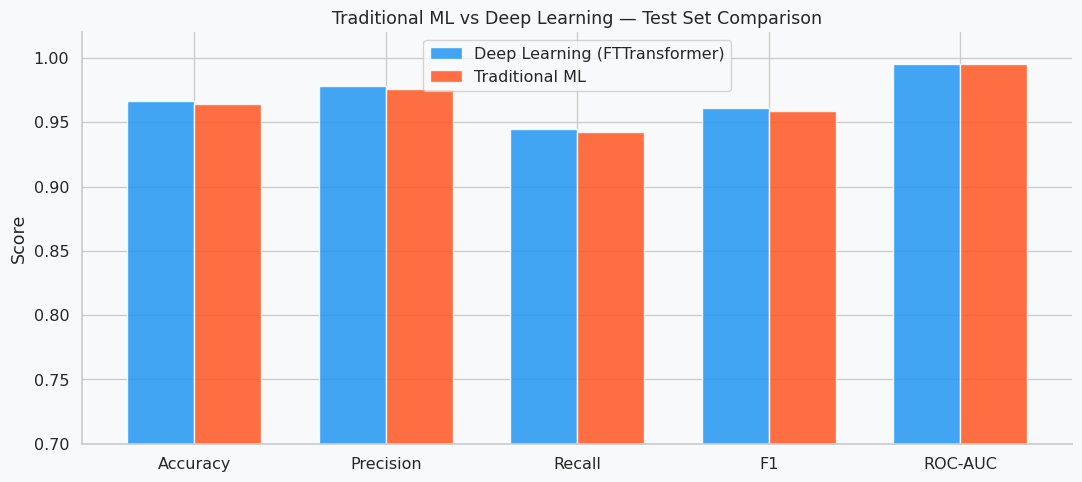


Best overall: Deep Learning (FTTransformer) (F1=0.9609, ROC-AUC=0.9955)


In [36]:
# 5. Final comparison
summary_rows = []

# Traditional
if 'tuned_pipe' in dir() or 'trad_pipe' in dir():
    _pipe = locals().get('tuned_pipe', globals().get('tuned_pipe', globals().get('trad_pipe')))
    _pred = _pipe.predict(X_test)
    _auc  = roc_auc_score(y_test, _pipe.predict_proba(X_test)[:,1]) if hasattr(_pipe, 'predict_proba') else float('nan')
    summary_rows.append({
        'Approach': 'Traditional ML',
        'Accuracy':  accuracy_score(y_test, _pred),
        'Precision': precision_score(y_test, _pred),
        'Recall':    recall_score(y_test, _pred),
        'F1':        f1_score(y_test, _pred),
        'ROC-AUC':   _auc,
    })

# Deep Learning
if 'preds_dl' in dir() or 'preds_r' in dir():
    _pdl   = locals().get('preds_dl', globals().get('preds_dl', preds_r))
    _probdl = locals().get('probs_dl', globals().get('probs_dl', probs_r))
    _ytdl   = locals().get('y_te_true_dl', y_true_r).astype(int)
    summary_rows.append({
        'Approach': f'Deep Learning ({best_dl_name if "best_dl_name" in globals() else best_dl_name_reload})',
        'Accuracy':  accuracy_score(_ytdl, _pdl),
        'Precision': precision_score(_ytdl, _pdl),
        'Recall':    recall_score(_ytdl, _pdl),
        'F1':        f1_score(_ytdl, _pdl),
        'ROC-AUC':   roc_auc_score(_ytdl, _probdl),
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows).sort_values('F1', ascending=False).reset_index(drop=True)
    summary_df['Rank'] = summary_df.index + 1
    display(summary_df[['Rank', 'Approach', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].round(4))

    # Bar chart
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
    x = np.arange(len(metrics))
    fig, ax = plt.subplots(figsize=(11, 5))
    w = 0.35 / max(1, len(summary_df) - 1)
    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(x + i * 0.35 - 0.175, [row[m] for m in metrics], 0.35,
               label=row['Approach'], color=PALETTE[i % len(PALETTE)], alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0.7, 1.02)
    ax.set_ylabel('Score')
    ax.set_title('Traditional ML vs Deep Learning — Test Set Comparison')
    ax.legend()
    plt.tight_layout()
    plt.show()

    best = summary_df.iloc[0]
    print(f'\nBest overall: {best["Approach"]} (F1={best["F1"]:.4f}, ROC-AUC={best["ROC-AUC"]:.4f})')
else:
    print('Hãy chạy Section 2 và Section 3 trước.')

---
## Checklist sản phẩm nộp

| Hạng mục | Trạng thái |
|----------|-----------|
| EDA đầy đủ (profiling, univariate, bivariate, multivariate) | Done |
| Pipeline truyền thống với scaling/SVD cấu hình được | Done |
| Model Zoo CV (6+ models) + selection log | Done |
| Hyperparameter tuning (RandomizedSearchCV) | Done |
| Evaluation: accuracy, precision, recall, F1, ROC-AUC | Done |
| Deep Learning pipeline (6 architectures + comparison) | Done |
| Features lưu .npy / .npz | Done |
| Model artifacts .joblib + .pt | Done |
| Cấu trúc thư mục: outputs/{artifacts, features, eda_outputs, deep_learning} | Done |
| Runtime → Run All chạy thành công | Done |
| Không mount Drive cá nhân | Done |
| Dataset tải từ Kaggle public | Done |